# **운전면허 보급과 교통안전 상관분석**

> 빅데이터분석_기말프로젝트_소프트웨어융합학과_2021111402_이예은

# 개발 환경 세팅

구글 드라이브 마운트

In [1]:
from google.colab import drive # 구글 드라이브 불러오기
drive.mount('/content/drive')

Mounted at /content/drive


라이브러리 설치

In [2]:
!pip install pandas requests scikit-learn matplotlib seaborn geopandas lightgbm shap

In [3]:
import pandas as pd
import os

from google.colab import drive
from IPython.display import display

# 시각화
import matplotlib.pyplot as plt
import matplotlib as mpl

import numpy as np
import seaborn as sns

# 한글 폰트 설치 & 적용
!apt-get update -qq
!apt-get install fonts-nanum -qq

from matplotlib import font_manager

# 나눔고딕 폰트 경로 찾기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic')
mpl.rc('axes', unicode_minus=False)  # 음수 기호 깨짐 방지


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126319 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


프로젝트 폴더 구조
- data/raw/ → 원본 CSV/XML/API에서 받은 데이터
- data/clean/ → 정제한(결측·이상치 처리한) 데이터
- notebooks/ → Jupyter 노트북(EDA·모델링)
- scripts/ → 수집·전처리 파이썬 스크립트

# 데이터셋 불러오기
: 각 파일을 pd.read_excel로 DataFrame으로 로드

> - 운전면허소지자 현황 : license.xlsx
- 자치구별 인구수(연령대) : population.xlsx
- 교통사고현황(사고유형별) : accident.xlsx
- 자치구별 인구밀도 : population_density.xlsx
- 자치구별 1인당 지역내총생산 및 수준지수 : per_capita_GDP.xlsx
- 자동차등록현황보고 : car_registration.xlsx

In [4]:
# 자치구별 면허 데이터 불러오기
license_df = pd.read_excel('/content/drive/MyDrive/License_Safety_Project/data/clean/license.xlsx')

# 자치구별 인구 통계
population_df = pd.read_excel('/content/drive/MyDrive/License_Safety_Project/data/clean/population.xlsx')

# 자치구별 교통사고 통계
accident_df = pd.read_excel('/content/drive/MyDrive/License_Safety_Project/data/clean/accident.xlsx')

# 자치구별 인구 밀도
population_density_df = pd.read_excel('/content/drive/MyDrive/License_Safety_Project/data/clean/population_density.xlsx')

# 자치구별 1인당 지역내총생산 및 수준지수
GDP_df = pd.read_excel('/content/drive/MyDrive/License_Safety_Project/data/clean/GDP.xlsx')

# 자동차 등록 현황 보고
car_registration_df = pd.read_excel('/content/drive/MyDrive/License_Safety_Project/data/clean/car_registration.xlsx')

# 데이터 전처리
- 컬럼명 표준화 : 모든 DataFrame에서 ‘지역코드’ 칼럼을 ‘region_code’로 통일

기본 구조 점검
- df.shape로 행·열 개수 확인
- df.columns.tolist()로 컬럼명을 리스트로 확보
- df.head() / df.info() / df.describe() 로 주요 값·타입·통계 요약 확인

컬럼 목록 추출
- 각 DataFrame의 columns.tolist() 결과를 모아 데이터별 컬럼 구성을 파악

면허 데이터 전처리 - license

In [5]:
# 지역코드 -> region_code 로 컬럼 이름 통일하기
license_df.rename(columns={'지역코드': 'region_code'}, inplace=True)

# '지역', 'region_code' 제외한 나머지 수치 컬럼만 int로 변환
acc_cols = [c for c in accident_df.columns if c not in ['지역','region_code']]
for col in acc_cols:
    accident_df[col] = (
        pd.to_numeric(accident_df[col].astype(str).str.replace(',',''), errors='coerce')
          .fillna(0)
          .astype(int)
    )

# 간단하게 체크하기
print("Shape:", license_df.shape)
print("\nColumns:", license_df.columns.tolist())

# 프리뷰 & 요약 출력
from IPython.display import display
display(license_df.head())
license_df.info()
display(license_df.describe())

Shape: (217, 6)

Columns: ['구명', 'region_code', '연령대', '1종소계', '2종소계', '2종 원자']


,구명,region_code,연령대,1종소계,2종소계,2종 원자
0,강남구,111261,10대,363,1334,48
1,강남구,111261,20대,10272,35533,109
2,강남구,111261,30대,25820,47744,111
3,강남구,111261,40대,44510,53522,102
4,강남구,111261,50대,43318,42708,129


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   구명           217 non-null    object
 1   region_code  217 non-null    int64 
 2   연령대          217 non-null    object
 3   1종소계         217 non-null    int64 
 4   2종소계         217 non-null    int64 
 5   2종 원자        217 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 10.3+ KB


,region_code,1종소계,2종소계,2종 원자
count,217.000000,217.000000,217.000000,217.000000
mean,111214.502304,14860.921659,13901.345622,128.271889
std,58.378088,13993.112590,12772.406521,89.705149
min,111123.000000,0.000000,1.000000,0.000000
25%,111152.000000,890.000000,1207.000000,62.000000
50%,111212.000000,12608.000000,12950.000000,118.000000
75%,111262.000000,25820.000000,22765.000000,186.000000
max,111311.000000,53753.000000,55986.000000,416.000000


In [6]:
license_agg = (
    license_df
    .groupby('region_code')[['1종소계','2종소계','2종 원자']]
    .sum()
    .reset_index()
)
license_agg['license_total'] = (
    license_agg['1종소계'] +
    license_agg['2종소계'] +
    license_agg['2종 원자']
)

교통 사고 데이터 정보 전처리 - accident

In [7]:
# 2) Standardize the column name
accident_df.rename(columns={'지역코드': 'region_code'}, inplace=True)

# 3) 나머지 컬럼을 숫자형으로 변환
num_cols = [c for c in accident_df.columns if c != 'region_code']
for col in num_cols:
    accident_df[col] = (
        pd.to_numeric(accident_df[col].astype(str).str.replace(',', ''), errors='coerce')
          .fillna(0)
          .astype(int)
    )

# 3) Quick checks
print("Shape:", accident_df.shape)
print("\nColumns:", accident_df.columns.tolist())

# 4) Preview and summary
from IPython.display import display
display(accident_df.head())
accident_df.info()
display(accident_df.describe())

Shape: (75, 7)

Columns: ['지역', 'region_code', '사고수', '합계', '차대사람', '차대차', '차량단독']


,지역,region_code,사고수,합계,차대사람,차대차,차량단독
0,0,111123,0,917,224,656,37
1,0,111123,0,5,4,1,0
2,0,111123,0,1253,232,941,80
3,0,111121,0,976,241,693,42
4,0,111121,0,16,14,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   지역           75 non-null     int64
 1   region_code  75 non-null     int64
 2   사고수          75 non-null     int64
 3   합계           75 non-null     int64
 4   차대사람         75 non-null     int64
 5   차대차          75 non-null     int64
 6   차량단독         75 non-null     int64
dtypes: int64(7)
memory usage: 4.2 KB


,지역,region_code,사고수,합계,차대사람,차대차,차량단독
count,75.0,75.000000,75.0,75.000000,75.000000,75.000000,75.000000
mean,0.0,111211.040000,0.0,1040.053333,208.613333,800.213333,31.226667
std,0.0,60.337215,0.0,986.811750,179.881485,797.219192,25.181274
min,0.0,111121.000000,0.0,2.000000,0.000000,0.000000,0.000000
25%,0.0,111152.000000,0.0,11.500000,5.000000,5.000000,2.000000
50%,0.0,111212.000000,0.0,1105.000000,240.000000,802.000000,35.000000
75%,0.0,111262.000000,0.0,1577.500000,326.000000,1141.500000,52.000000
max,0.0,111311.000000,0.0,4863.000000,834.000000,3959.000000,80.000000


In [8]:
# 전처리된 accident_df 기준으로 acc_agg 정의
# num_cols 는 'region_code'를 제외한 수치형 컬럼 리스트
num_cols = [c for c in accident_df.columns if c != 'region_code']

acc_agg = (
    accident_df
      .groupby('region_code')['합계']
      .sum()
      .reset_index()
      .rename(columns={'합계':'accidents'})
)

# 결과 확인
print(acc_agg.head())

   region_code  accidents
0       111121       2228
1       111123       2175
2       111131       2054
3       111141       1807
4       111142       2081


자치구별 인구수 데이터 전처리 - population

In [9]:
# 2) Standardize the column name
population_df.rename(columns={'지역코드': 'region_code'}, inplace=True)

# region_code랑 '행정기관' 제외하고 숫자형으로 변환
pop_cols = [c for c in population_df.columns if c not in ['region_code','행정기관']]
for col in pop_cols:
    population_df[col] = (
        pd.to_numeric(population_df[col].astype(str).str.replace(',',''), errors='coerce')
          .fillna(0)
          .astype(int)
    )

# 3) Quick checks
print("Shape:", population_df.shape)
print("\nColumns:", population_df.columns.tolist())

# 4) Preview and summary
display(population_df.head())
population_df.info()
display(population_df.describe(include='all'))

Shape: (26, 41)

Columns: ['region_code', '행정기관', '총 거주자수', '연령구간인구수', '0~9세', '10~19세', '20~29세', '30~39세', '40~49세', '50~59세', '60~69세', '70~79세', '80~89세', '90~99세', '100세 이상', '남 거주자수', '연령구간인구수.1', '0~9세.1', '10~19세.1', '20~29세.1', '30~39세.1', '40~49세.1', '50~59세.1', '60~69세.1', '70~79세.1', '80~89세.1', '90~99세.1', '100세 이상.1', '여 거주자수', '연령구간인구수.2', '0~9세.2', '10~19세.2', '20~29세.2', '30~39세.2', '40~49세.2', '50~59세.2', '60~69세.2', '70~79세.2', '80~89세.2', '90~99세.2', '100세 이상.2']


,region_code,행정기관,총 거주자수,연령구간인구수,0~9세,10~19세,20~29세,30~39세,40~49세,50~59세,...,10~19세.2,20~29세.2,30~39세.2,40~49세.2,50~59세.2,60~69세.2,70~79세.2,80~89세.2,90~99세.2,100세 이상.2
0,110000,서울특별시,9313144,9313144,510390,730047,1346933,1418471,1404422,1478356,...,356282,708435,708938,709951,753141,686928,402951,202061,33202,1050
1,111123,서울특별시 종로구,137560,137560,5857,9673,21386,19106,18916,23357,...,4934,11288,9556,9778,11802,10185,6210,3949,644,30
2,111121,서울특별시 중구,119762,119762,5588,6084,17374,20773,16504,18698,...,3021,9487,10379,8118,9369,9036,5695,3433,651,19
3,111131,서울특별시 용산구,208787,208787,10958,13434,29561,36958,30557,33277,...,6577,15995,18611,15425,17054,14611,8546,5400,969,41
4,111142,서울특별시 성동구,274893,274893,16780,17726,40648,45469,40419,43832,...,8873,20961,23212,20159,22306,19502,11216,6322,913,27


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 41 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   region_code  26 non-null     int64 
 1   행정기관         26 non-null     object
 2   총 거주자수       26 non-null     int64 
 3   연령구간인구수      26 non-null     int64 
 4   0~9세         26 non-null     int64 
 5   10~19세       26 non-null     int64 
 6   20~29세       26 non-null     int64 
 7   30~39세       26 non-null     int64 
 8   40~49세       26 non-null     int64 
 9   50~59세       26 non-null     int64 
 10  60~69세       26 non-null     int64 
 11  70~79세       26 non-null     int64 
 12  80~89세       26 non-null     int64 
 13  90~99세       26 non-null     int64 
 14  100세 이상      26 non-null     int64 
 15  남 거주자수       26 non-null     int64 
 16  연령구간인구수.1    26 non-null     int64 
 17  0~9세.1       26 non-null     int64 
 18  10~19세.1     26 non-null     int64 
 19  20~29세.1     26 non-null     in

,region_code,행정기관,총 거주자수,연령구간인구수,0~9세,10~19세,20~29세,30~39세,40~49세,50~59세,...,10~19세.2,20~29세.2,30~39세.2,40~49세.2,50~59세.2,60~69세.2,70~79세.2,80~89세.2,90~99세.2,100세 이상.2
count,26.000000,26,2.600000e+01,2.600000e+01,26.000000,26.000000,2.600000e+01,2.600000e+01,2.600000e+01,2.600000e+01,...,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
unique,NaN,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,서울특별시,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,111164.461538,NaN,7.163957e+05,7.163957e+05,39260.769231,56157.461538,1.036102e+05,1.091132e+05,1.080325e+05,1.137197e+05,...,27406.307692,54495.000000,54533.692308,54611.615385,57933.923077,52840.615385,30996.230769,15543.153846,2554.000000,80.769231
std,244.949828,NaN,1.757798e+06,1.757798e+06,96480.242669,138176.660624,2.543053e+05,2.678368e+05,2.653081e+05,2.789885e+05,...,67421.269599,133756.442961,133882.152605,134169.378044,142139.326213,129654.483728,76026.752931,38105.918511,6263.597126,198.089941
min,110000.000000,NaN,1.197620e+05,1.197620e+05,5588.000000,6084.000000,1.737400e+04,1.910600e+04,1.650400e+04,1.869800e+04,...,3021.000000,9487.000000,9556.000000,8118.000000,9369.000000,9036.000000,5695.000000,3433.000000,644.000000,19.000000
25%,111151.250000,NaN,3.036310e+05,3.036310e+05,15397.500000,22024.500000,4.249200e+04,4.475125e+04,4.242525e+04,5.017325e+04,...,10785.000000,22149.500000,22768.750000,21230.750000,25293.750000,22477.750000,13453.750000,6807.750000,1169.000000,36.250000
50%,111206.500000,NaN,3.780490e+05,3.780490e+05,20223.500000,25397.000000,5.637100e+04,5.699700e+04,5.516650e+04,5.907650e+04,...,12454.000000,29427.000000,28769.000000,27612.000000,30130.500000,27337.000000,17005.000000,8232.000000,1291.000000,41.000000
75%,111261.750000,NaN,4.616292e+05,4.616292e+05,25977.500000,40948.750000,6.399700e+04,6.760975e+04,7.179300e+04,7.308575e+04,...,19773.500000,32841.750000,34324.500000,37432.750000,37090.500000,33038.750000,20368.500000,9546.750000,1587.000000,45.000000


자치구별 인구 밀도 데이터 전처리 - population_density

In [10]:
# 2) Standardize the column name
population_density_df.rename(columns={'지역코드': 'region_code'}, inplace=True)

# Convert all other columns to int
for col in population_df.columns:
    if col != 'region_code':
        population_df[col] = (
            pd.to_numeric(population_df[col].astype(str).str.replace(',', ''), errors='coerce')
              .fillna(0)
              .astype(int)
        )

# 3) Quick checks
print("Shape:", population_density_df.shape)
print("Columns:", population_density_df.columns.tolist())

# 4) Preview and summary
display(population_density_df.head())
population_density_df.info()
display(population_density_df.describe())

Shape: (26, 5)
Columns: ['지역', 'region_code', '인구 (명)', '면적 (㎢)', '인구밀도 (명/㎢)']


,지역,region_code,인구 (명),면적 (㎢),인구밀도 (명/㎢)
0,소계,0,9597372,605.21,15858
1,종로구,111123,149608,23.91,6256
2,중구,111121,131214,9.96,13174
3,용산구,111131,217194,21.87,9932
4,성동구,111142,281289,16.82,16723


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   지역           26 non-null     object 
 1   region_code  26 non-null     int64  
 2   인구 (명)       26 non-null     int64  
 3   면적 (㎢)       26 non-null     float64
 4   인구밀도 (명/㎢)   26 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.1+ KB


,region_code,인구 (명),면적 (㎢),인구밀도 (명/㎢)
count,26.000000,2.600000e+01,26.000000,26.000000
mean,106933.692308,7.382594e+05,46.555000,16637.153846
std,21810.361697,1.811176e+06,114.308431,4626.613861
min,0.000000,1.312140e+05,9.960000,6256.000000
25%,111151.250000,3.091795e+05,17.465000,14072.250000
50%,111206.500000,3.922625e+05,23.730000,16450.000000
75%,111261.750000,4.774430e+05,29.675000,19528.500000
max,111311.000000,9.597372e+06,605.210000,25226.000000


1인당, 자치구별 GDP 데이터 전처리 - GDP

In [11]:
# 2) Standardize the column name
GDP_df.rename(columns={'지역코드': 'region_code'}, inplace=True)

# Convert all other columns (except region_code) to numeric, preserving float where needed
for col in GDP_df.columns:
    if col != 'region_code':
        GDP_df[col] = (
            pd.to_numeric(GDP_df[col].astype(str).str.replace(',', ''), errors='coerce')
              .fillna(0)
        )

# 3) Quick checks
print("Shape:", GDP_df.shape)
print("Columns:", GDP_df.columns.tolist())

# 4) Preview and summary
display(GDP_df.head())
GDP_df.info()
display(GDP_df.describe(include='all'))

Shape: (26, 7)
Columns: ['자치구', 'region_code', '지역내총생산(당해년가격) (백만원)', '구성비 (%)', '인구(추계인구) (명)', '1인당 지역내총생산 (천원)', '수준지수(서울특별시=100) (%)']


,자치구,region_code,지역내총생산(당해년가격) (백만원),구성비 (%),인구(추계인구) (명),1인당 지역내총생산 (천원),수준지수(서울특별시=100) (%)
0,0.0,0,472040199,100.0,9501528,49680,100.00
1,0.0,111123,35719537,7.6,149705,238599,480.27
2,0.0,111121,61342710,13.0,127427,481395,968.98
3,0.0,111131,13294640,2.8,225647,58918,118.59
4,0.0,111142,13999893,3.0,287580,48682,97.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   자치구                  26 non-null     float64
 1   region_code          26 non-null     int64  
 2   지역내총생산(당해년가격) (백만원)  26 non-null     int64  
 3   구성비 (%)              26 non-null     float64
 4   인구(추계인구) (명)         26 non-null     int64  
 5   1인당 지역내총생산 (천원)      26 non-null     int64  
 6   수준지수(서울특별시=100) (%)  26 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 1.6 KB


,자치구,region_code,지역내총생산(당해년가격) (백만원),구성비 (%),인구(추계인구) (명),1인당 지역내총생산 (천원),수준지수(서울특별시=100) (%)
count,26.0,26.000000,2.600000e+01,26.000000,2.600000e+01,26.000000,26.000000
mean,0.0,106933.692308,3.631078e+07,7.684615,7.308868e+05,65314.846154,131.470000
std,0.0,21810.361697,9.085492e+07,19.249949,1.792741e+06,99721.297744,200.725271
min,0.0,0.000000,3.462961e+06,0.700000,1.274270e+05,11139.000000,22.420000
25%,0.0,111151.250000,6.594432e+06,1.400000,3.115465e+05,15180.250000,30.552500
50%,0.0,111206.500000,1.132935e+07,2.400000,3.926235e+05,30751.000000,61.900000
75%,0.0,111261.750000,2.922557e+07,6.150000,4.572090e+05,58840.000000,118.435000
max,0.0,111311.000000,4.720402e+08,100.000000,9.501528e+06,481395.000000,968.980000


자동차 등록 현황 데이터 전처리 - car_registration

In [12]:
# Rename '지역코드' to 'region_code'
# If there is a column for district name (e.g., '시군구' or similar), rename to 'region_name'
car_registration_df.rename(columns={'지역코드': 'region_code'}, inplace=True)

# '시군구','region_code' 제외하고 숫자형으로 변환
car_cols = [c for c in car_registration_df.columns if c not in ['시군구','region_code']]
for col in car_cols:
    car_registration_df[col] = (
        pd.to_numeric(car_registration_df[col].astype(str).str.replace(',',''), errors='coerce')
          .fillna(0)
          .astype(int)
    )

# 3) Quick checks
print("Shape:", car_registration_df.shape)
print("Columns:", car_registration_df.columns.tolist())

# 4) Preview and summary
display(car_registration_df.head())
car_registration_df.info()
display(car_registration_df.describe(include='all'))

Shape: (27, 22)
Columns: ['시군구', 'region_code', '승용', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', '승합', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', '화물', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', '특수', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', '총계', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21']


,시군구,region_code,승용,Unnamed: 3,Unnamed: 4,Unnamed: 5,승합,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,특수,Unnamed: 15,Unnamed: 16,Unnamed: 17,총계,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,NaN,지역코드,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,강남구,111261,161,218351,13948,232460,60,3833,541,4434,...,2204,15941,19,376,152,547,427,236110,16845,253382
2,강동구,111274,109,143721,5083,148913,41,3212,623,3876,...,2630,14682,7,262,213,482,305,159099,8549,167953
3,강북구,111291,114,59999,2093,62206,68,1998,715,2781,...,1263,8025,15,152,114,281,325,68783,4185,73293
4,강서구,111212,137,167147,8660,175944,45,3974,1308,5327,...,4278,20260,17,451,264,732,362,187391,14510,202263


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   시군구          26 non-null     object
 1   region_code  27 non-null     object
 2   승용           27 non-null     int64 
 3   Unnamed: 3   27 non-null     int64 
 4   Unnamed: 4   27 non-null     int64 
 5   Unnamed: 5   27 non-null     int64 
 6   승합           27 non-null     int64 
 7   Unnamed: 7   27 non-null     int64 
 8   Unnamed: 8   27 non-null     int64 
 9   Unnamed: 9   27 non-null     int64 
 10  화물           27 non-null     int64 
 11  Unnamed: 11  27 non-null     int64 
 12  Unnamed: 12  27 non-null     int64 
 13  Unnamed: 13  27 non-null     int64 
 14  특수           27 non-null     int64 
 15  Unnamed: 15  27 non-null     int64 
 16  Unnamed: 16  27 non-null     int64 
 17  Unnamed: 17  27 non-null     int64 
 18  총계           27 non-null     int64 
 19  Unnamed: 19  27 non-null     in

,시군구,region_code,승용,Unnamed: 3,Unnamed: 4,Unnamed: 5,승합,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,특수,Unnamed: 15,Unnamed: 16,Unnamed: 17,총계,Unnamed: 19,Unnamed: 20,Unnamed: 21
count,26,27,27.000000,2.700000e+01,27.000000,2.700000e+01,27.000000,27.000000,27.000000,27.000000,...,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,2.700000e+01,27.000000,2.700000e+01
unique,26,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,강남구,지역코드,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,355.851852,1.968656e+05,8272.518519,2.054939e+05,274.148148,4848.222222,1078.666667,6201.037037,...,4399.185185,22365.333333,31.925926,450.444444,381.185185,863.555556,951.851852,2.198404e+05,14131.555556,2.349239e+05
std,NaN,NaN,940.626089,4.941370e+05,20900.256685,5.158136e+05,749.851509,12143.418598,2720.165606,15528.595846,...,11048.119221,56071.327460,81.728879,1130.480202,962.240896,2169.395934,2467.277396,5.516670e+05,35534.808169,5.894982e+05
min,NaN,NaN,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,NaN,NaN,92.000000,7.663550e+04,2401.500000,8.076600e+04,44.500000,1976.500000,284.000000,2703.500000,...,1633.500000,8998.000000,10.500000,174.000000,105.500000,306.000000,302.000000,8.559800e+04,4880.000000,9.244900e+04
50%,NaN,NaN,114.000000,9.860800e+04,3410.000000,1.017300e+05,55.000000,2591.000000,568.000000,3216.000000,...,2187.000000,11800.000000,14.000000,203.000000,168.000000,382.000000,325.000000,1.104700e+05,7293.000000,1.165410e+05
75%,NaN,NaN,149.000000,1.278195e+05,5811.000000,1.331125e+05,84.000000,3148.000000,742.000000,3803.500000,...,2705.000000,14956.500000,17.500000,273.000000,258.000000,559.000000,420.500000,1.412475e+05,9314.000000,1.503835e+05


# 파생 변수 생성

> - license_rate:	인구 대비 면허 보유 비율
- vehicle_rate:	인구 대비 등록 차량 수 비율
- accident_rate:	인구 대비 사고 발생률
- fatality_rate:	사고 대비 사망 비율 (치명률, 사망자수 ÷ 총 사고 건수)
- injury_rate:	사고 대비 부상 비율 (부상자수 ÷ 총 사고 건수)
- accident_per_vehicle:	차량 1대당 사고 발생률 (총 사고 건수 ÷ 총 차량 수)
- accident_per_license:	면허 1명당 사고 발생률 (총 사고 건수 ÷ 총 면허 소지자 수)
- accident_per_gdp:	총 GDP 대비 사고 건수 비율 (총 사고 건수 ÷ 총 GDP(백만원))
- gdp_per_capita:	자치구 1인당 GRDP (천원 단위)

### 파생 지표 생성을 위한 추가 전처리

In [13]:
import numpy as np

# —————————————————————————————————————————————————————————
# (가정) 기존에 아래 변수가 이미 정의되어 있는 상태:
# license_agg, acc_agg, df_accident, population_df, population_density_df, car_registration_df, GDP_df
# —————————————————————————————————————————————————————————

# 1) 교통사고(acc_agg) 컬럼 점검
print("▶ acc_agg 컬럼:", acc_agg.columns.tolist())

# 2) car_registration_df 총 차량 수 생성(‘총계’ 컬럼 사용)
print("▶ car_registration_df 컬럼:", car_registration_df.columns.tolist())
if '총계' not in car_registration_df.columns:
    raise KeyError("'총계' 컬럼이 car_registration_df에 없습니다.")
car_registration_df['total_vehicles'] = car_registration_df['총계']

# 3) GDP_df 컬럼명 점검
print("▶ GDP_df 컬럼:", GDP_df.columns.tolist())
gdp_rename_map = {}
if '지역내총생산(당해년가격) (백만원)' in GDP_df.columns:
    gdp_rename_map['지역내총생산(당해년가격) (백만원)'] = 'total_gdp'
if '1인당 지역내총생산 (천원)' in GDP_df.columns:
    gdp_rename_map['1인당 지역내총생산 (천원)'] = 'gdp_per_capita'
GDP_df = GDP_df.rename(columns=gdp_rename_map)
if 'total_gdp' not in GDP_df.columns or 'gdp_per_capita' not in GDP_df.columns:
    raise KeyError("GDP_df에 'total_gdp' 또는 'gdp_per_capita' 컬럼이 없습니다.")

# 4) 자치구별 통합 DataFrame 생성
merged_df = license_agg.merge(
    acc_agg[['region_code','accidents']],
    on='region_code', how='inner'
).merge(
    population_df[['region_code','총 거주자수']],
    on='region_code', how='inner'
).merge(
    population_density_df[['region_code','인구밀도 (명/㎢)']],
    on='region_code', how='inner'
).merge(
    car_registration_df[['region_code','total_vehicles']],
    on='region_code', how='inner'
).merge(
    GDP_df[['region_code','total_gdp','gdp_per_capita']],
    on='region_code', how='inner'
)

print("\n▶ merged_df 컬럼:", merged_df.columns.tolist())
display(merged_df.head())

▶ acc_agg 컬럼: ['region_code', 'accidents']
▶ car_registration_df 컬럼: ['시군구', 'region_code', '승용', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', '승합', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', '화물', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', '특수', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', '총계', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21']
▶ GDP_df 컬럼: ['자치구', 'region_code', '지역내총생산(당해년가격) (백만원)', '구성비 (%)', '인구(추계인구) (명)', '1인당 지역내총생산 (천원)', '수준지수(서울특별시=100) (%)']

▶ merged_df 컬럼: ['region_code', '1종소계', '2종소계', '2종 원자', 'license_total', 'accidents', '총 거주자수', '인구밀도 (명/㎢)', 'total_vehicles', 'total_gdp', 'gdp_per_capita']


,region_code,1종소계,2종소계,2종 원자,license_total,accidents,총 거주자수,인구밀도 (명/㎢),total_vehicles,total_gdp,gdp_per_capita
0,111123,44682,56811,774,102267,2175,137560,6256,3609,35719537,238599
1,111131,66616,90723,753,158092,2054,208787,9932,550,13294640,58918
2,111141,115366,113874,1425,230665,1807,332794,20433,305,6554954,18732
3,111142,90140,97370,1084,188594,2081,274893,16723,380,13999893,48682
4,111151,139737,98969,1640,240346,2830,380302,20832,249,4860242,12742


### 파생 변수 지표 생성
- 생성한 모든 파생 지표는 merged_df에 저장

In [14]:
# 5) 파생 지표 생성
# 5-1) 면허율
merged_df['license_rate'] = merged_df['license_total'] / merged_df['총 거주자수']

# 5-2) 차량 비율
merged_df['vehicle_rate'] = merged_df['total_vehicles'] / merged_df['총 거주자수']

# 5-3) 사고율
merged_df['accident_rate'] = merged_df['accidents'] / merged_df['총 거주자수']

# 5-4) 치명률(fatality_rate)
#    acc_agg에는 deaths(사망자수) 컬럼이 없을 수 있으므로,
#    먼저 확인하고 없으면 0으로 채움
if 'deaths' in acc_agg.columns:
    merged_df = merged_df.merge(
        acc_agg[['region_code','deaths']],
        on='region_code', how='left'
    )
    merged_df['deaths'] = merged_df['deaths'].fillna(0).astype(int)
else:
    merged_df['deaths'] = 0

merged_df['fatality_rate'] = np.where(
    merged_df['accidents'] > 0,
    merged_df['deaths'] / merged_df['accidents'],
    0
)

# 5-5) 부상률(injury_rate)
#    acc_agg에 injuries(부상자수) 컬럼이 없으면 0으로 채움
if 'injuries' in acc_agg.columns:
    merged_df = merged_df.merge(
        acc_agg[['region_code','injuries']],
        on='region_code', how='left'
    )
    merged_df['injuries'] = merged_df['injuries'].fillna(0).astype(int)
else:
    merged_df['injuries'] = 0

merged_df['injury_rate'] = np.where(
    merged_df['accidents'] > 0,
    merged_df['injuries'] / merged_df['accidents'],
    0
)

# 5-6) 차량 1대당 사고 발생률
merged_df['accident_per_vehicle'] = np.where(
    merged_df['total_vehicles'] > 0,
    merged_df['accidents'] / merged_df['total_vehicles'],
    0
)

# 5-7) 면허 1명당 사고 발생률
merged_df['accident_per_license'] = np.where(
    merged_df['license_total'] > 0,
    merged_df['accidents'] / merged_df['license_total'],
    0
)

# 5-8) GDP 대비 사고 건수 비율
merged_df['accident_per_gdp'] = np.where(
    merged_df['total_gdp'] > 0,
    merged_df['accidents'] / merged_df['total_gdp'],
    0
)

# 5-9) gdp_per_capita 컬럼은 이미 존재하므로 생략

# 6) 파생지표 결과 확인
pd.set_option('display.float_format', lambda x: f"{x:.4f}")
print("\n▶ 파생 지표 예시:")
display(
    merged_df[[
        'region_code',
        'license_rate','vehicle_rate','accident_rate',
        'fatality_rate','injury_rate',
        'accident_per_vehicle','accident_per_license',
        'accident_per_gdp','gdp_per_capita'
    ]].head(10)
)


▶ 파생 지표 예시:


,region_code,license_rate,vehicle_rate,accident_rate,fatality_rate,injury_rate,accident_per_vehicle,accident_per_license,accident_per_gdp,gdp_per_capita
0,111123,0.7434,0.0262,0.0158,0.0000,0.0000,0.6027,0.0213,0.0001,238599
1,111131,0.7572,0.0026,0.0098,0.0000,0.0000,3.7345,0.0130,0.0002,58918
2,111141,0.6931,0.0009,0.0054,0.0000,0.0000,5.9246,0.0078,0.0003,18732
3,111142,0.6861,0.0014,0.0076,0.0000,0.0000,5.4763,0.0110,0.0001,48682
4,111151,0.6320,0.0007,0.0074,0.0000,0.0000,11.3655,0.0118,0.0006,12742
5,111152,0.6694,0.0009,0.0101,0.0000,0.0000,11.1759,0.0151,0.0004,22164
6,111161,0.6517,0.0007,0.0069,0.0000,0.0000,10.2133,0.0106,0.0005,14608
7,111171,0.6333,0.0009,0.0039,0.0000,0.0000,4.3406,0.0062,0.0003,11233
8,111181,0.6360,0.0006,0.0060,0.0000,0.0000,9.3133,0.0095,0.0005,11139
9,111191,0.6768,0.0015,0.0064,0.0000,0.0000,4.2772,0.0094,0.0002,28793


# 상관관계 분석

### 면허율, 사고율의 상관관계

In [15]:
print(accident_df.columns.tolist())
print(acc_agg.head())

['지역', 'region_code', '사고수', '합계', '차대사람', '차대차', '차량단독']
   region_code  accidents
0       111121       2228
1       111123       2175
2       111131       2054
3       111141       1807
4       111142       2081


면허율, 사고율 계산

In [16]:
# 면허율, 사고율 계산
license_rates = license_agg.merge(
    population_df[['region_code','총 거주자수']], on='region_code')

license_rates['license_rate'] = license_rates['license_total'] / license_rates['총 거주자수']

accident_rates = acc_agg.merge(
    population_df[['region_code','총 거주자수']], on='region_code')

accident_rates['accident_rate'] = (
    accident_rates['accidents'] / accident_rates['총 거주자수'])

# 확인
display(license_rates.head())
display(accident_rates.head())

,region_code,1종소계,2종소계,2종 원자,license_total,총 거주자수,license_rate
0,111123,44682,56811,774,102267,137560,0.7434
1,111131,66616,90723,753,158092,208787,0.7572
2,111141,115366,113874,1425,230665,332794,0.6931
3,111142,90140,97370,1084,188594,274893,0.6861
4,111151,139737,98969,1640,240346,380302,0.6320


,region_code,accidents,총 거주자수,accident_rate
0,111121,2228,119762,0.0186
1,111123,2175,137560,0.0158
2,111131,2054,208787,0.0098
3,111141,1807,332794,0.0054
4,111142,2081,274893,0.0076


면허율과 사고율의 상관관계

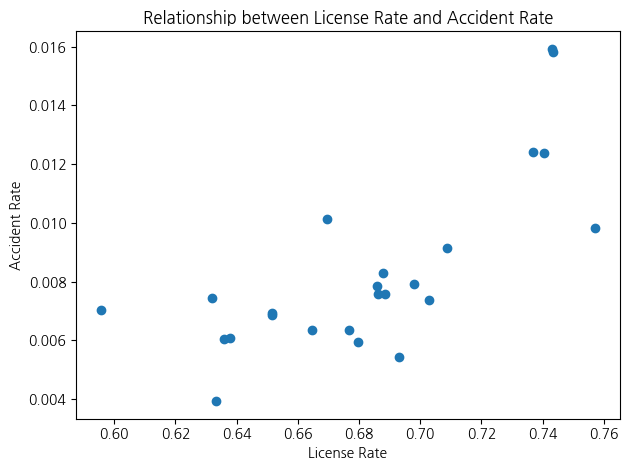

In [17]:
# 1) Merge license_rates and accident_rates into a single DataFrame
rates_df = pd.merge(
    license_rates[['region_code', 'license_rate']],
    accident_rates[['region_code', 'accident_rate']],
    on='region_code'
)

# 시각화
# 2) Scatter plot: License Rate vs Accident Rate
plt.figure()
plt.scatter(rates_df['license_rate'], rates_df['accident_rate'])
plt.xlabel('License Rate')
plt.ylabel('Accident Rate')
plt.title('Relationship between License Rate and Accident Rate')
plt.tight_layout()
plt.show()

### GRDP과 사고율 상관관계

Correlation between per-capita GRDP and accident rate: 0.872


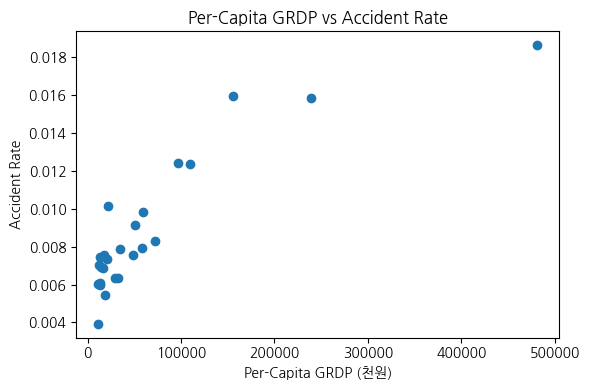

In [18]:
# 3) accident_rates 랑 GDP per capita merge하기
df = accident_rates.merge(
    GDP_df[['region_code', 'gdp_per_capita']],
    on='region_code',
    how='left'
)

# 4) corr 생성
corr = df['accident_rate'].corr(df['gdp_per_capita'])
print(f"Correlation between per-capita GRDP and accident rate: {corr:.3f}")

# 5) 산점도 그래프 시각화
plt.figure(figsize=(6, 4))
plt.scatter(df['gdp_per_capita'], df['accident_rate'])
plt.xlabel('Per-Capita GRDP (천원)')
plt.ylabel('Accident Rate')
plt.title('Per-Capita GRDP vs Accident Rate')
plt.tight_layout()
plt.show()

### 자동차 등록대수와 사고율 상관관계

In [19]:
# accident types by region_code 합치기 sum()
acc_pivot = (
    accident_df
    .groupby('region_code')[['차대사람', '차대차', '차량단독']]
    .sum()
    .reset_index()
)


print(acc_pivot.head())

   region_code  차대사람   차대차  차량단독
0       111121   506  1634    88
1       111123   460  1598   117
2       111131   352  1639    63
3       111141   379  1395    33
4       111142   392  1640    49


  region_code  total_vehicles
0           0           12850
1      111121            1298
2      111123            3609
3      111131             550
4      111141             305
Correlation between total registered vehicles and accidents per 10k vehicles: -0.501


/tmp/ipython-input-20-154581037.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf with NaN


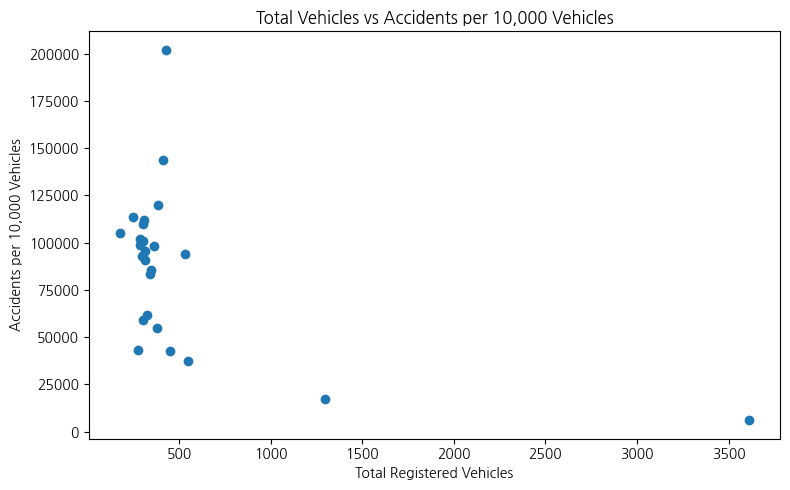

In [20]:
# Sum registered vehicles by region_code
car_pivot = (
    car_registration_df
      .groupby('region_code')[['총계']]
      .sum()
      .reset_index()
      .rename(columns={'총계':'total_vehicles'})
)

print(car_pivot.head())

# Merge accident data and car registration data
df_merged = acc_pivot.merge(car_pivot, on='region_code', how='left')

# Calculate accident rate per 10,000 vehicles (example metric)
# Handle potential division by zero
df_merged['accidents_per_10k_vehicles'] = (
    (df_merged[['차대사람', '차대차', '차량단독']].sum(axis=1) /
     df_merged['total_vehicles']) * 10000
)
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf with NaN
df_merged.dropna(subset=['accidents_per_10k_vehicles', 'total_vehicles'], inplace=True) # Drop rows with NaN

# Compute correlation between total vehicles and accidents per 10k vehicles
corr_vehicles = df_merged['total_vehicles'].corr(df_merged['accidents_per_10k_vehicles'])
print(f"Correlation between total registered vehicles and accidents per 10k vehicles: {corr_vehicles:.3f}")

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df_merged['total_vehicles'], df_merged['accidents_per_10k_vehicles'])
plt.xlabel('Total Registered Vehicles')
plt.ylabel('Accidents per 10,000 Vehicles')
plt.title('Total Vehicles vs Accidents per 10,000 Vehicles')
plt.tight_layout()
plt.show()

### 인구밀도와 사고율의 상관관계

In [21]:
# 1) 사고 합계(합계 컬럼)를 지역별로 집계
acc_agg = (accident_df
           .groupby('region_code')['합계']
           .sum()
           .reset_index()
           .rename(columns={'합계':'accidents'}))

population_df['총 거주자수'] = pd.to_numeric(
    population_df['총 거주자수'].astype(str).str.replace(',',''),
    errors='coerce'
).fillna(0).astype(int)

# 2) 사고율 계산
accident_rates = acc_agg.merge(
    population_df[['region_code','총 거주자수']],
    on='region_code'
)
accident_rates['accident_rate'] = (
    accident_rates['accidents'] / accident_rates['총 거주자수']
)

# 3) 병합
df_corr = accident_rates.merge(
    population_density_df[['region_code','인구밀도 (명/㎢)']],
    on='region_code',
    how='inner'
)

# 4) 값 분포 점검
print(df_corr[['accident_rate','인구밀도 (명/㎢)']].describe())

# 5) 상관계수 계산
corr_value = df_corr['인구밀도 (명/㎢)'].corr(df_corr['accident_rate'])
print(f"Correlation: {corr_value:.3f}")

       accident_rate  인구밀도 (명/㎢)
count        25.0000     25.0000
mean          0.0088  16668.3200
std           0.0036   4719.2316
min           0.0039   6256.0000
25%           0.0064  14010.0000
50%           0.0076  16723.0000
75%           0.0098  19580.0000
max           0.0186  25226.0000
Correlation: -0.418


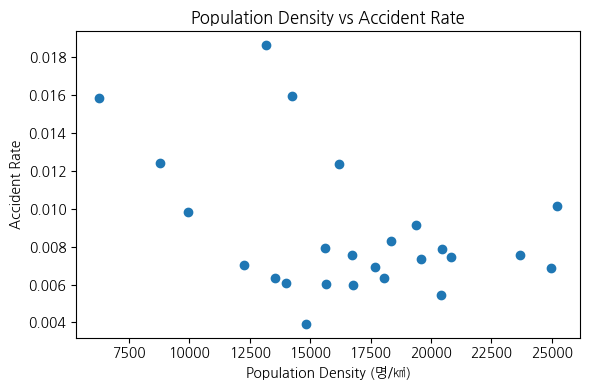

In [22]:
# 시각화
# Scatter plot
plt.figure(figsize=(6, 4))
plt.scatter(df_corr['인구밀도 (명/㎢)'], df_corr['accident_rate'])
plt.xlabel('Population Density (명/㎢)')
plt.ylabel('Accident Rate')
plt.title('Population Density vs Accident Rate')
plt.tight_layout()
plt.show()

### 사고가 많은 자치구 상위 10개 대상, 사고 유형 비율 분석

/tmp/ipython-input-23-194390022.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accident_types_df['합계'] = accident_types_df[['차대사람', '차대차', '차량단독']].sum(axis=1)
/tmp/ipython-input-23-194390022.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-23-194390022.py:57: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 레이아웃 자동 조정
/tmp/ipython-input-23-194390022.py:57: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 레이아웃 자동 조정
/tmp/ipython-input-23-194390022.py:57: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.t

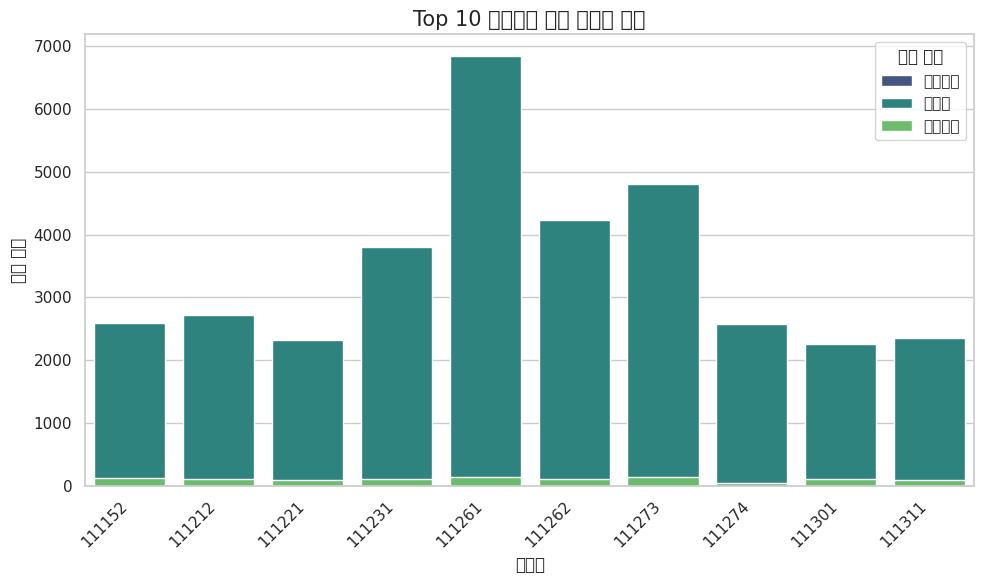

In [23]:
# 사고 유형별 분포를 위해 필요한 컬럼만 선택
accident_types_df = accident_df[['region_code', '차대사람', '차대차', '차량단독']]

# '합계' 컬럼 생성 (각 사고 유형의 합)
accident_types_df['합계'] = accident_types_df[['차대사람', '차대차', '차량단독']].sum(axis=1)

# 합계 기준으로 상위 10개 자치구 선택
top_10_districts = (
    accident_types_df
    .groupby('region_code')['합계']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# 상위 10개 자치구 데이터 필터링
accident_top10 = accident_types_df[accident_types_df['region_code'].isin(top_10_districts)]

# 시각화를 위해 데이터 재구성
accident_top10_melted = accident_top10.melt(
    id_vars=['region_code'],
    value_vars=['차대사람', '차대차', '차량단독'],
    var_name='사고유형',
    value_name='사고건수'
)

# 각 자치구별 사고 유형 합계 계산
accident_top10_agg = (
    accident_top10_melted
    .groupby(['region_code', '사고유형'])['사고건수']
    .sum()
    .reset_index()
)

# 시각화
# 스택형 바 차트 시각화
plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")
sns.barplot(
    x='region_code',
    y='사고건수',
    hue='사고유형',
    data=accident_top10_agg,
    estimator=sum,
    ci=None,
    palette='viridis',
    dodge=False # 스택형으로 만들기 위해 False
)

plt.title('Top 10 자치구의 사고 유형별 분포', fontsize=15)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('사고 건수', fontsize=12)
plt.xticks(rotation=45, ha='right') # 자치구 이름이 겹치지 않도록 회전
plt.legend(title='사고 유형')
plt.tight_layout() # 레이아웃 자동 조정
plt.show()

# EDA (상관분석 + 시각화)

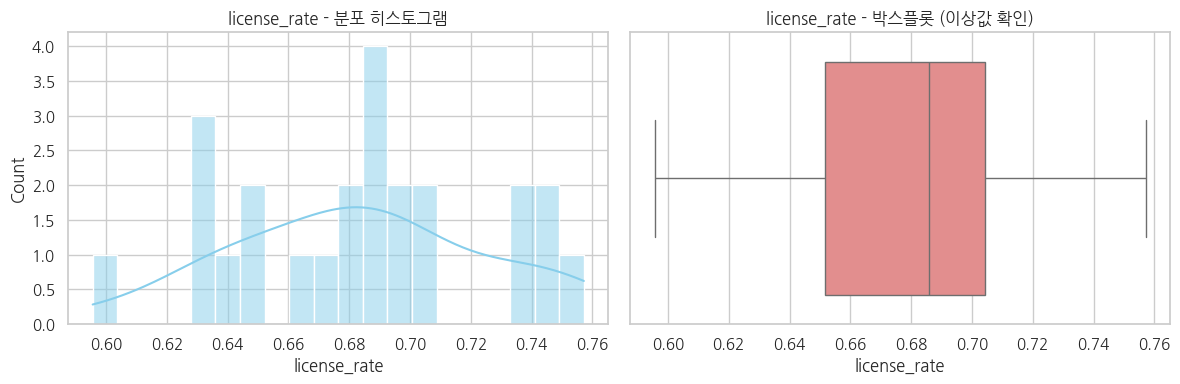

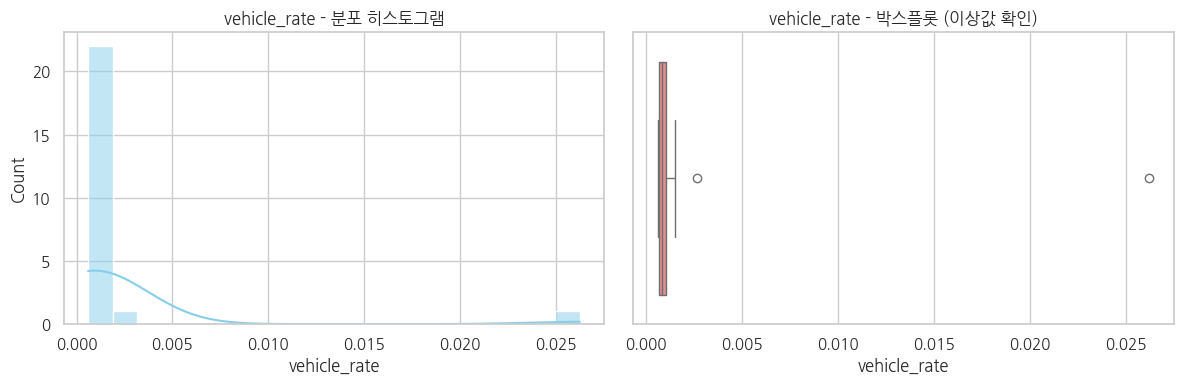

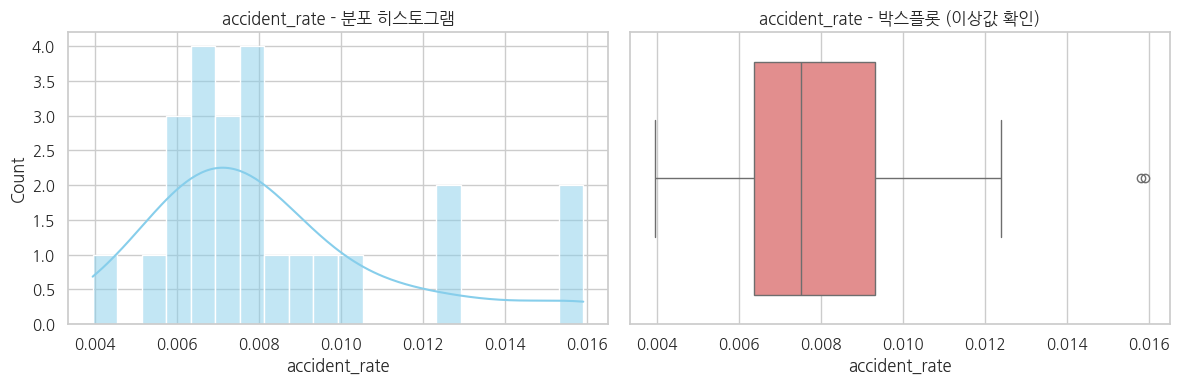

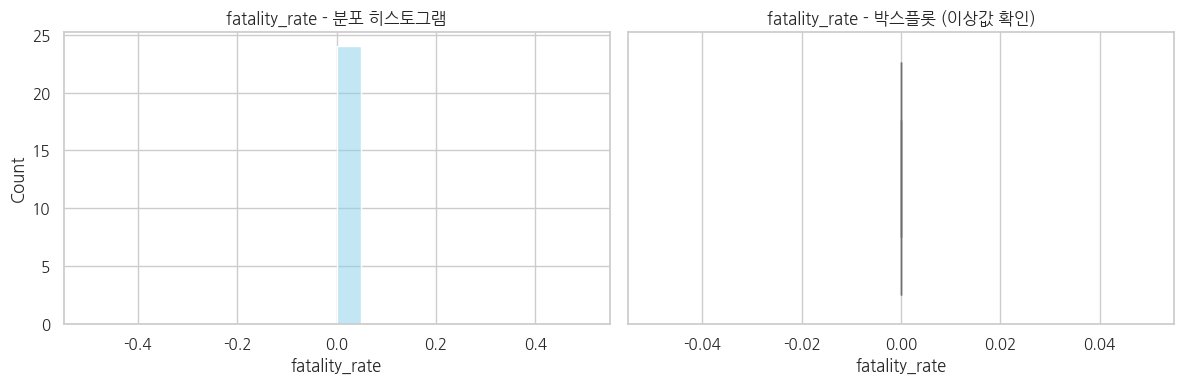

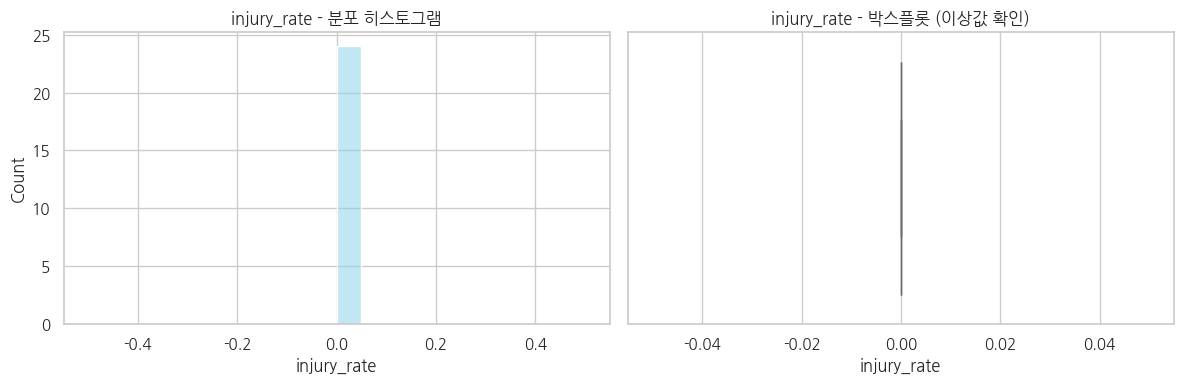

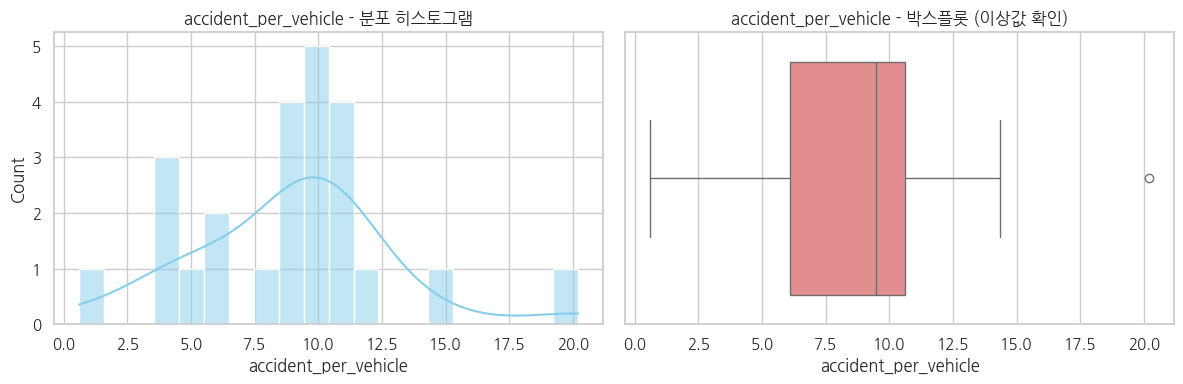

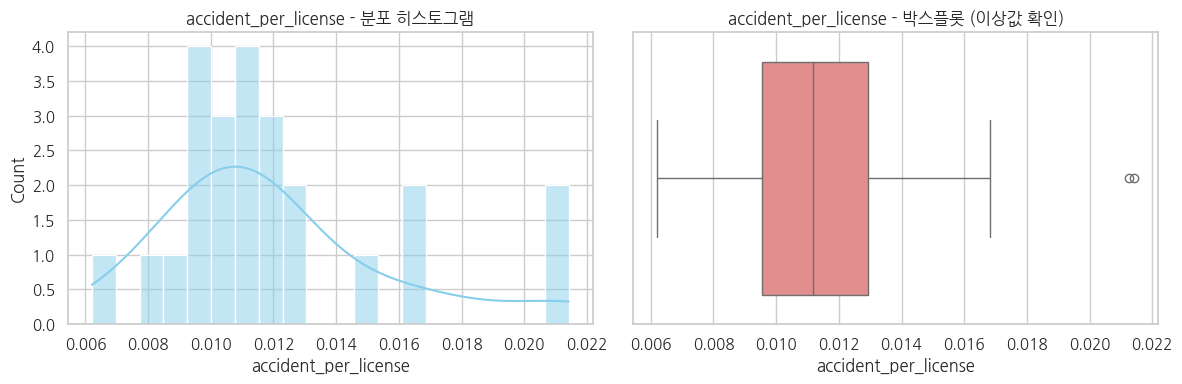

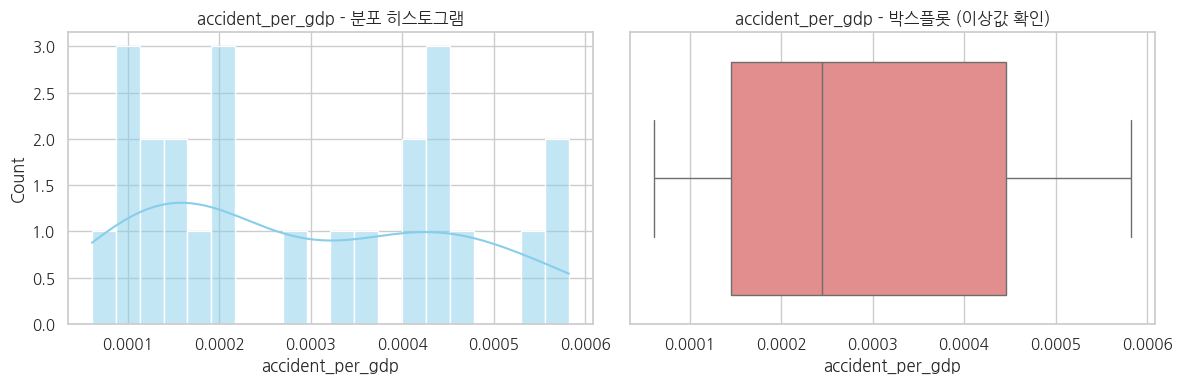

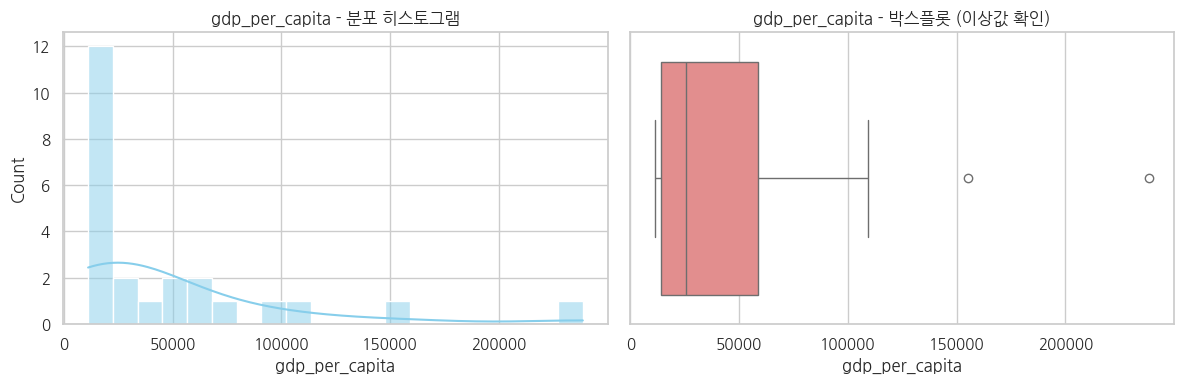

/tmp/ipython-input-24-2109500016.py:36: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


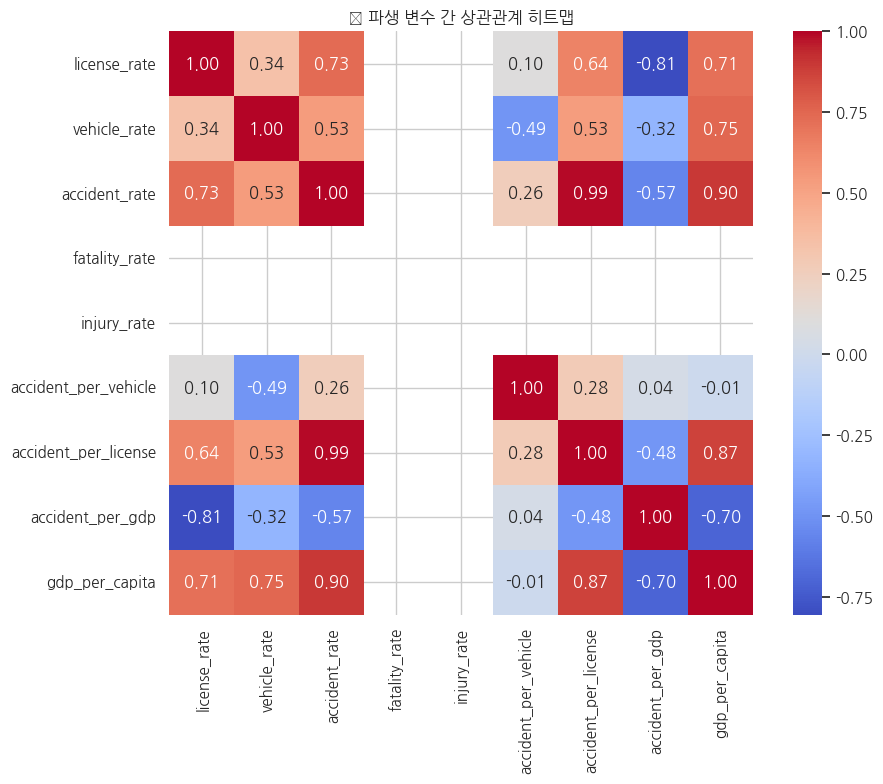

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


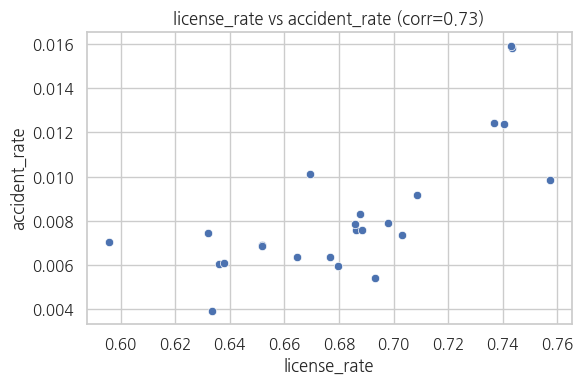

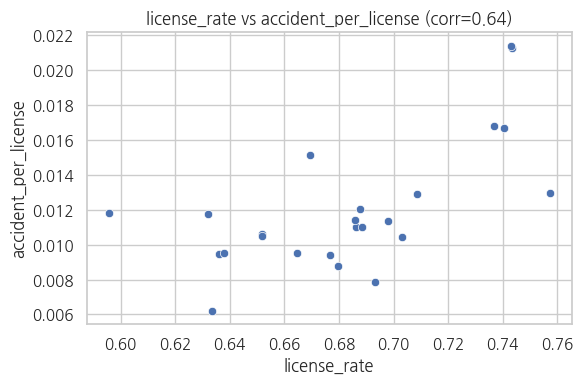

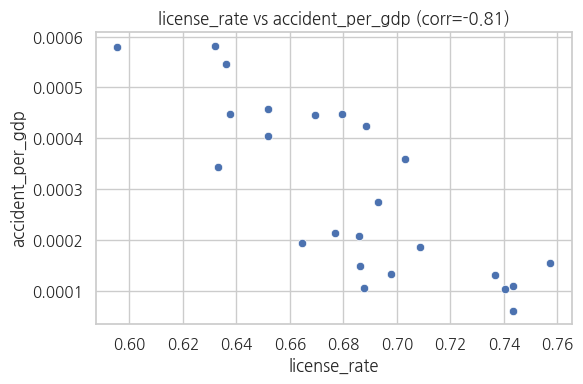

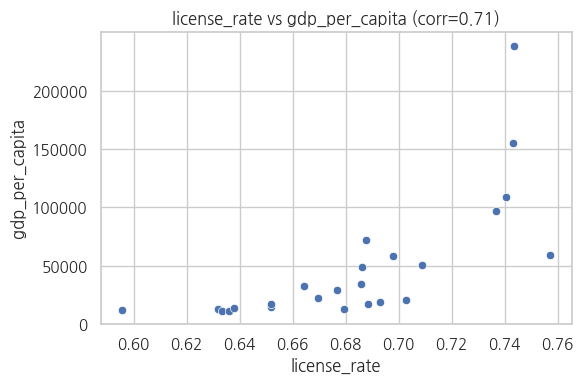

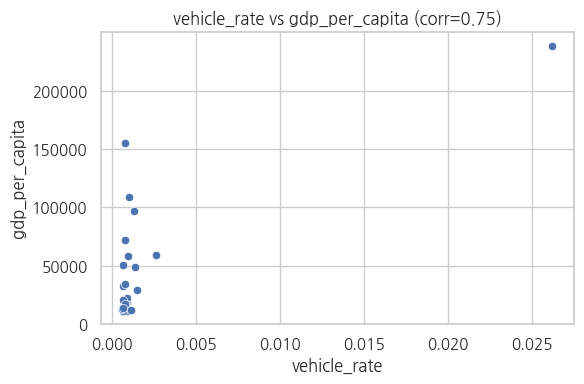

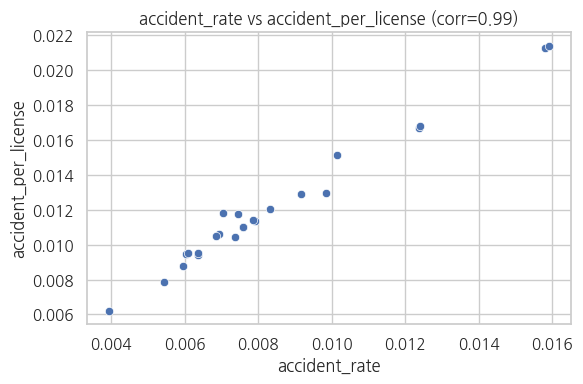

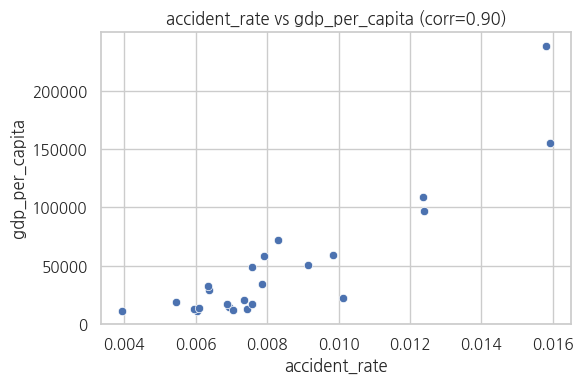

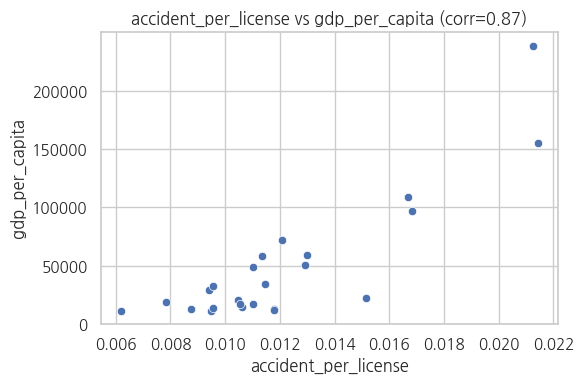

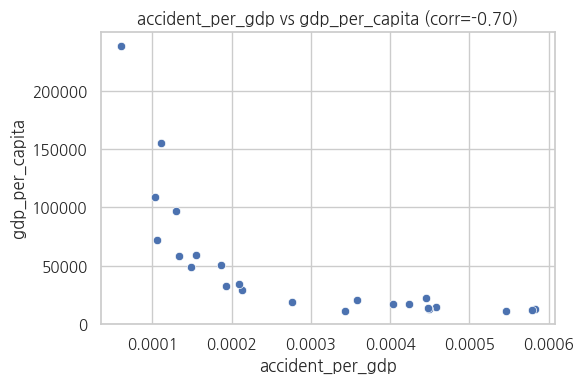

이상값 포함 자치구 수: 1


,region_code,license_rate,vehicle_rate,accident_rate,fatality_rate,injury_rate,accident_per_vehicle,accident_per_license,accident_per_gdp,gdp_per_capita
0,111123,0.7434,0.0262,0.0158,0.0000,0.0000,0.6027,0.0213,0.0001,238599


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# 한글 폰트 설정 (colab용)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 분석 대상 파생 변수 목록
eda_vars = [
    'license_rate', 'vehicle_rate', 'accident_rate',
    'fatality_rate', 'injury_rate',
    'accident_per_vehicle', 'accident_per_license',
    'accident_per_gdp', 'gdp_per_capita'
]

# 1) 히스토그램 & 박스플롯
for col in eda_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(merged_df[col], bins=20, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} - 분포 히스토그램')

    sns.boxplot(x=merged_df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} - 박스플롯 (이상값 확인)')

    plt.tight_layout()
    plt.show()

# 2) 상관관계 히트맵
corr_matrix = merged_df[eda_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("📌 파생 변수 간 상관관계 히트맵")
plt.tight_layout()
plt.show()

# 3) 주요 상관조합 산점도 (상위 상관계수 조합만)
from itertools import combinations

high_corr_pairs = []
for x, y in combinations(eda_vars, 2):
    corr_val = merged_df[x].corr(merged_df[y])
    if abs(corr_val) > 0.6:
        high_corr_pairs.append((x, y, corr_val))

# 시각화
for x, y, corr_val in high_corr_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=merged_df[x], y=merged_df[y])
    plt.title(f'{x} vs {y} (corr={corr_val:.2f})')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

# 4) 이상값 탐지 (z-score 기준)
z_scores = merged_df[eda_vars].apply(zscore)
outlier_flags = (np.abs(z_scores) > 3).sum(axis=1)
outliers = merged_df[outlier_flags > 0]

print(f"이상값 포함 자치구 수: {outliers.shape[0]}")
display(outliers[['region_code'] + eda_vars])

# 서울시 지도 공간 시각화
- 서울시 자치구 경계(GeoJSON/Shape)와 병합하여 Choropleth 제작

GeoDataFrame(GDF) 내부 확인

In [25]:
import geopandas as gpd

# 1) GeoJSON을 gdf로 읽어오기
geo_path = '/content/drive/MyDrive/License_Safety_Project/data/clean/Seoul_geo.geojson'
gdf = gpd.read_file(geo_path)

# 2) 컬럼 확인
print("GeoJSON 컬럼 목록:", gdf.columns.tolist())
# 예를 들어 ['SIG_CD','SIG_KOR_NM','geometry'] 처럼 나와야 합니다.

# 3) geometry 타입 확인
print("geometry 타입:", type(gdf.loc[0, 'geometry']))
# → shapely.geometry.polygon.Polygon 이어야 합니다.

# 4) CRS(좌표계) 확인
print("GeoDataFrame CRS:", gdf.crs)
# → EPSG:4326 혹은 EPSG:5179 등으로 나오면 정상입니다.

GeoJSON 컬럼 목록: ['SIG_CD', 'SIG_ENG_NM', 'SIG_KOR_NM', 'geometry']
geometry 타입: <class 'shapely.geometry.polygon.Polygon'>
GeoDataFrame CRS: EPSG:4326


병합된 DataFrame 확인

In [26]:
# 1) merged_df: 이전에 만든 통합 DataFrame (파생 지표 포함)
# 2) gdf: GeoDataFrame

# a) GeoDataFrame에 병합할 때 사용한 ‘region_code’ 컬럼 확인
print("merged_df의 region_code 예시:\n", merged_df['region_code'].head())

# b) gdf에도 동일한 region_code 가 있는지 확인
#    (GeoJSON 파일에서 사용되는 컬럼명이 ‘SIG_CD’라고 가정 후, 문자열로 바꿔두었다고 봅니다.)
gdf['region_code'] = gdf['SIG_CD'].astype(str)
print("gdf의 region_code 예시:\n", gdf['region_code'].head())

# c) 실제 병합 진행
gdf_merged = gdf.merge(
    merged_df[['region_code', 'accident_rate']],
    on='region_code',
    how='left'
)

# d) 병합 결과 확인: 몇 개의 값을 제대로 가져왔는지 본다
print("병합 후 gdf_merged에 남은 행 수:", len(gdf_merged))
print("accident_rate가 NaN이 아닌 개수:",
      gdf_merged['accident_rate'].notna().sum(), "/", len(gdf_merged))

# e) 상위 몇 개만 살펴보기
print("\n▶ gdf_merged.head():")
display(gdf_merged[['region_code','SIG_KOR_NM','accident_rate']].head(10))

merged_df의 region_code 예시:
 0    111123
1    111131
2    111141
3    111142
4    111151
Name: region_code, dtype: object
gdf의 region_code 예시:
 0    11110
1    11140
2    11170
3    11200
4    11215
Name: region_code, dtype: object
병합 후 gdf_merged에 남은 행 수: 25
accident_rate가 NaN이 아닌 개수: 0 / 25

▶ gdf_merged.head():


,region_code,SIG_KOR_NM,accident_rate
0,11110,종로구,NaN
1,11140,중구,NaN
2,11170,용산구,NaN
3,11200,성동구,NaN
4,11215,광진구,NaN
5,11230,동대문구,NaN
6,11260,중랑구,NaN
7,11290,성북구,NaN
8,11305,강북구,NaN
9,11320,도봉구,NaN


merged_df와 gdf 병합 상태 확인

In [27]:
merged_df['region_code'] = merged_df['region_code'].astype(str).str.strip()
print("merged_df region_code 예시:", merged_df['region_code'].head())

merged_df region_code 예시: 0    111123
1    111131
2    111141
3    111142
4    111151
Name: region_code, dtype: object


In [28]:
# 1) GeoDataFrame에도 region_code가 올바르게 만들어졌는지 확인
print("gdf['region_code'] 예시:")
print(gdf['region_code'].head(10))

# 2) merged_df와 gdf 사이 병합 후 결과 확인
gdf_merged = gdf.merge(
    merged_df[['region_code', 'accident_rate']],
    on='region_code',
    how='left'
)

# 결과 간단하게 출력해서 확인하기
print("\n병합 후 gdf_merged의 총 행 수:", len(gdf_merged))
print("accident_rate가 NaN이 아닌 행 수:", gdf_merged['accident_rate'].notna().sum(), "/", len(gdf_merged))
print("\n▶ gdf_merged['accident_rate'] 요약 통계:")
print(gdf_merged['accident_rate'].describe())

print("\n▶ gdf_merged 샘플 (상위 10행):")
display(gdf_merged[['region_code','SIG_KOR_NM','accident_rate']].head(10))

gdf['region_code'] 예시:
0    11110
1    11140
2    11170
3    11200
4    11215
5    11230
6    11260
7    11290
8    11305
9    11320
Name: region_code, dtype: object

병합 후 gdf_merged의 총 행 수: 25
accident_rate가 NaN이 아닌 행 수: 0 / 25

▶ gdf_merged['accident_rate'] 요약 통계:
count   0.0000
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN
Name: accident_rate, dtype: float64

▶ gdf_merged 샘플 (상위 10행):


,region_code,SIG_KOR_NM,accident_rate
0,11110,종로구,NaN
1,11140,중구,NaN
2,11170,용산구,NaN
3,11200,성동구,NaN
4,11215,광진구,NaN
5,11230,동대문구,NaN
6,11260,중랑구,NaN
7,11290,성북구,NaN
8,11305,강북구,NaN
9,11320,도봉구,NaN


병합 후 전체 행: 34
사고율 0 이상 행: 34
사고율 분포:
 count   34.0000
mean     0.0023
std      0.0041
min      0.0000
25%      0.0000
50%      0.0000
75%      0.0051
max      0.0158
Name: accident_rate, dtype: float64


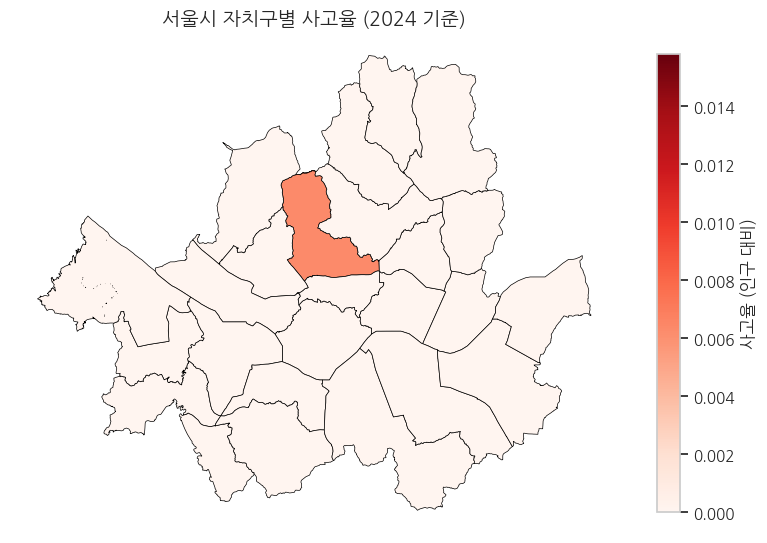

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# ── 1) GeoJSON 불러오기 ───────────────────────────────────────────────
geo_path = '/content/drive/MyDrive/License_Safety_Project/data/clean/Seoul_geo.geojson'
gdf = gpd.read_file(geo_path)

# ── 2) 병합할 DataFrame 준비 ───────────────────────────────────────────
# (merged_df는 기존에 생성된 통합 DataFrame)
# 6자리 region_code → 5자리 자치구 코드로 변환
merged_df['region_code5'] = (
    merged_df['region_code'].astype(str).str[:4] + '0'
)

# ── 3) GeoDataFrame에도 5자리 코드 설정 ─────────────────────────────────
gdf['region_code5'] = gdf['SIG_CD'].astype(str).str.strip()

# (필요 시 CRS 맞추기)
# print("Before CRS:", gdf.crs)
# gdf = gdf.to_crs(epsg=4326)
# print("After CRS:", gdf.crs)

# ── 4) 병합 ────────────────────────────────────────────────────────────
gdf_merged = gdf.merge(
    merged_df[['region_code5','accident_rate']],
    on='region_code5',
    how='left'
)

# ── 5) NaN 처리 & 값 확인 ───────────────────────────────────────────────
# NaN은 0으로 대체 (사고율 0인 자치구 처리)
gdf_merged['accident_rate'] = gdf_merged['accident_rate'].fillna(0)

print("병합 후 전체 행:", len(gdf_merged))
print("사고율 0 이상 행:", (gdf_merged['accident_rate'] >= 0).sum())
print("사고율 분포:\n", gdf_merged['accident_rate'].describe())

# ── 6) 컬러 범위 수동 설정 ─────────────────────────────────────────────
vmin = 0
vmax = gdf_merged['accident_rate'].max()

# ── 7) Choropleth 지도 그리기 ─────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
gdf_merged.plot(
    column='accident_rate',
    cmap='Reds',
    vmin=vmin,
    vmax=vmax,
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "사고율 (인구 대비)", 'shrink': 0.6},
    ax=ax
)
ax.set_title('서울시 자치구별 사고율 (2024 기준)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

# 클러스터링 (K-means)

클리스터링

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# 클러스터링 대상 변수
cluster_features = [
    'license_rate', 'vehicle_rate', 'accident_rate',
    'fatality_rate', 'accident_per_license',
    'accident_per_vehicle', 'accident_per_gdp', 'gdp_per_capita'
]

# 1. 결측치 제거 및 지역코드 포함
cluster_df = merged_df[['region_code'] + cluster_features].dropna()

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])

# 3. 최적 클러스터 수 탐색 (2~8 범위)
silhouette_scores = {}
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

# 4. 최적 K 선택
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"▶ 최적 K: {best_k}, Silhouette Score: {silhouette_scores[best_k]:.3f}")

# 5. 최종 모델 학습 및 클러스터 할당
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)
cluster_df['cluster'] = cluster_labels

# 6. 병합하여 활용 가능하게 만듦
merged_df = merged_df.merge(cluster_df[['region_code', 'cluster']], on='region_code', how='left')

# 7. 클러스터별 평균값 확인
cluster_profile = (
    cluster_df
    .groupby('cluster')[cluster_features]
    .mean()
    .round(4)
)

# 결과 출력
print("▶ 클러스터 프로파일")
display(cluster_profile)

▶ 최적 K: 2, Silhouette Score: 0.514
▶ 클러스터 프로파일


,license_rate,vehicle_rate,accident_rate,fatality_rate,accident_per_license,accident_per_vehicle,accident_per_gdp,gdp_per_capita
cluster,,,,,,,,
0,0.7410,0.0073,0.0141,0.0000,0.0191,10.5518,0.0001,149960.0000
1,0.6718,0.0009,0.0072,0.0000,0.0107,8.6544,0.0003,28363.5500


클러스터별 주요 파생지표 분포 시각화 (Boxplot)

/tmp/ipython-input-31-2122950256.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=merged_df, palette='Set2')
/tmp/ipython-input-31-2122950256.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=merged_df, palette='Set2')
/tmp/ipython-input-31-2122950256.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=merged_df, palette='Set2')
/tmp/ipython-input-31-2122950256.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

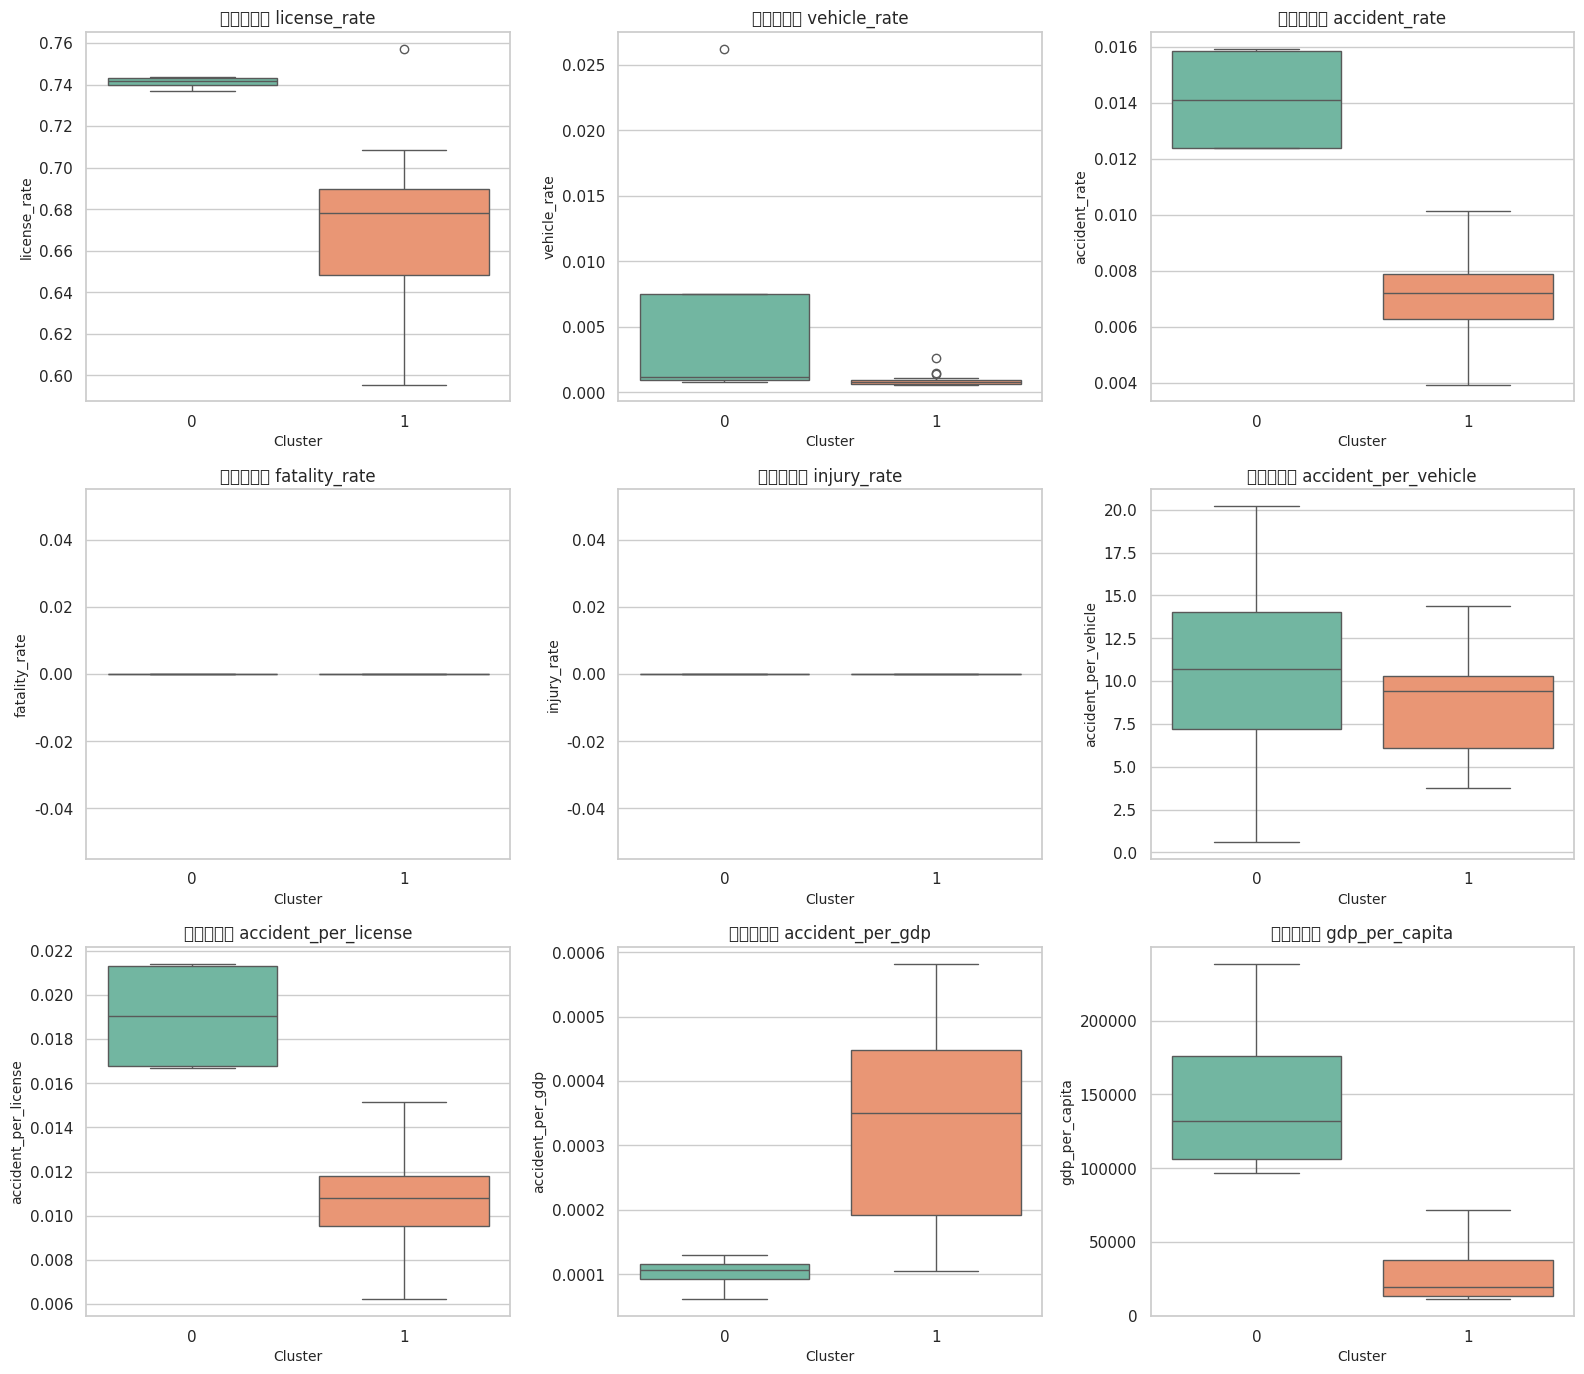

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 사용할 파생 변수 목록
features = [
    'license_rate', 'vehicle_rate', 'accident_rate',
    'fatality_rate', 'injury_rate',
    'accident_per_vehicle', 'accident_per_license',
    'accident_per_gdp', 'gdp_per_capita'
]

# 시각화 스타일 설정
sns.set(style="whitegrid")
plt.figure(figsize=(16, 18))

# 피처별 Boxplot 반복 생성
for i, feature in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x='cluster', y=feature, data=merged_df, palette='Set2')
    plt.title(f'클러스터별 {feature}', fontsize=12)
    plt.xlabel('Cluster', fontsize=10)
    plt.ylabel(feature, fontsize=10)

plt.tight_layout()
plt.show()

# 분류 모델링

- 자치구 데이터를 기반으로 “고사고 위험지역(Cluster 0)”을 분류하는 모델

데이터 준비 & 전처리

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 사용 변수 정의
features = [
    'license_rate', 'vehicle_rate', 'accident_rate',
    'fatality_rate', 'injury_rate',
    'accident_per_vehicle', 'accident_per_license',
    'accident_per_gdp', 'gdp_per_capita'
]

X = merged_df[features]
y = merged_df['cluster']

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Random Forest 모델 학습

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 모델 훈련
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 예측 및 평가
y_pred = rf.predict(X_test_scaled)
print("Random Forest 성능 평가")
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1]))

Random Forest 성능 평가
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

ROC AUC Score: 1.0


XGBoost 모델 학습

In [34]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_scaled, y_train)

# 예측 및 평가
y_pred_xgb = xgb_clf.predict(X_test_scaled)
print("⚡ XGBoost 성능 평가")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, xgb_clf.predict_proba(X_test_scaled)[:,1]))

⚡ XGBoost 성능 평가
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

ROC AUC Score: 1.0


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:46:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


변수 중요도 시각화

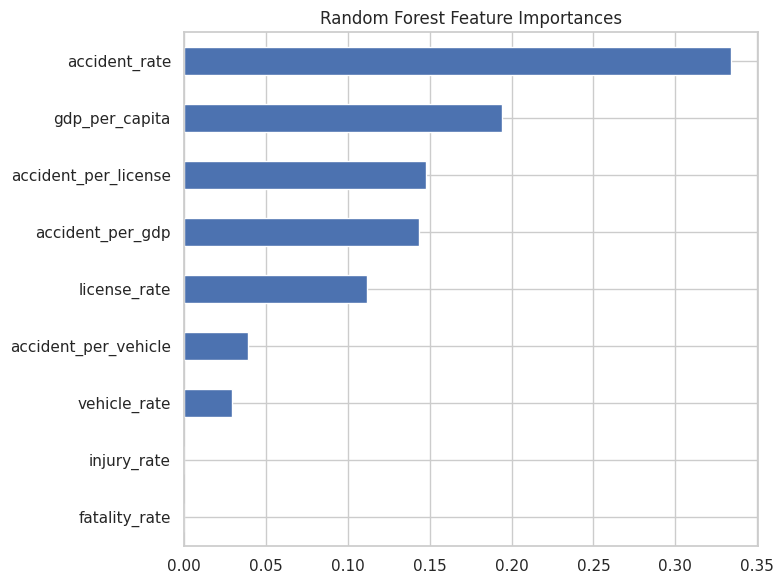

In [35]:
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# 예측 모델링
- 분류 & 회귀
- (1) 회귀 모델로 사고율 예측
- (2) 분류 모델로 고위험 지역 예측


1. 회귀 모델로 사고율 예측

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 19, number of used features: 0
[LightGBM] [Info] Start training from score 0.007753
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spli

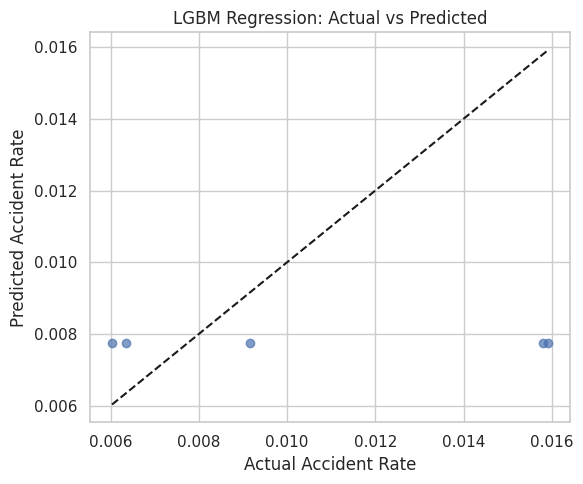

In [36]:
# 9. 예측 모델링: 분류 & 회귀

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # numpy import 추가

# ── (1) 회귀 모델로 사고율 예측 ─────────────────────────────────────────
# 특성 변수 정의 (이전과 동일)
features = [
    'license_rate', 'vehicle_rate', 'accident_per_vehicle',
    'accident_per_license', 'accident_per_gdp',
    'gdp_per_capita'
]

# 입력(X)과 목표(y_reg)
X_reg = merged_df[features]
y_reg = merged_df['accident_rate']

# 학습/테스트 분리
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(Xr_train, yr_train)
yr_pred_rf = rf_reg.predict(Xr_test)

# LightGBM Regressor
lgb_reg = LGBMRegressor(n_estimators=100, random_state=42)
lgb_reg.fit(Xr_train, yr_train)
yr_pred_lgb = lgb_reg.predict(Xr_test)

# 평가 함수
def regression_metrics(y_true, y_pred, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    # squared=False 제거하고, np.sqrt를 사용하여 직접 RMSE 계산
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2  = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")

# 결과 출력
regression_metrics(yr_test, yr_pred_rf,  "RandomForestRegressor")
regression_metrics(yr_test, yr_pred_lgb, "LGBMRegressor")

# 예측 vs 실제 산점도
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(yr_test, yr_pred_lgb, alpha=0.7)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'k--')
plt.xlabel("Actual Accident Rate")
plt.ylabel("Predicted Accident Rate")
plt.title("LGBM Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

2. 분류 모델로 고위험 지역 예측

In [37]:
# ── (2) 분류 모델로 고위험 지역 예측 ────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 상위 20% 사고율을 고위험(label=1)으로 분류
threshold = merged_df['accident_rate'].quantile(0.8)
merged_df['high_risk'] = (merged_df['accident_rate'] >= threshold).astype(int)

X_clf = merged_df[features]
y_clf = merged_df['high_risk']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

# RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(Xc_train, yc_train)
yc_pred = rf_clf.predict(Xc_test)
yc_proba = rf_clf.predict_proba(Xc_test)[:,1]

# 출력
print("RandomForestClassifier\n", classification_report(yc_test, yc_pred))
print("ROC AUC:", roc_auc_score(yc_test, yc_proba))

RandomForestClassifier
               precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5

ROC AUC: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 가설 검증, 시각화

In [38]:
# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

1. 가설 1: 면허율이 높을수록 사고율이 낮다


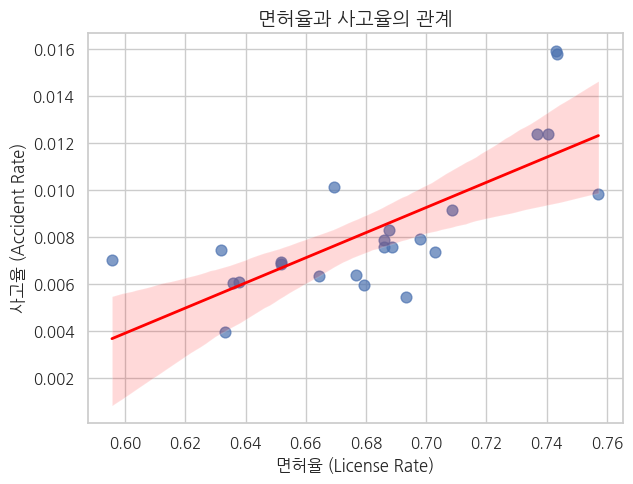

In [39]:
# 1. 가설 1: 면허율이 높을수록 사고율이 낮다
plt.figure(figsize=(6.5, 5))
sns.regplot(
    x='license_rate',
    y='accident_rate',
    data=merged_df,
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('면허율과 사고율의 관계', fontsize=14)
plt.xlabel('면허율 (License Rate)', fontsize=12)
plt.ylabel('사고율 (Accident Rate)', fontsize=12)
plt.tight_layout()
plt.show()

가설 1: 면허율 외에 다른 운전 관련 지표와의 상관관계도 함께 시각화 (heatmap)

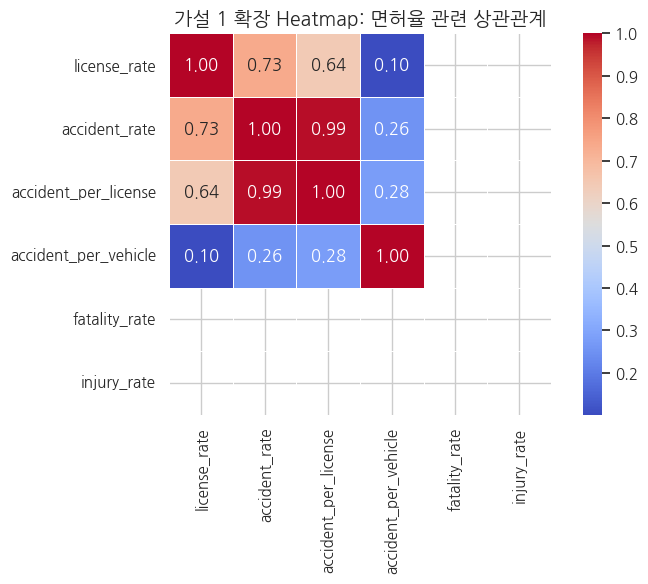

In [40]:
# 가설 1 관련 heatmap
hypo1_cols = [
    'license_rate',
    'accident_rate',
    'accident_per_license',
    'accident_per_vehicle',
    'fatality_rate',
    'injury_rate'
]
plt.figure(figsize=(8, 6))
sns.heatmap(
    merged_df[hypo1_cols].corr(),
    annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, square=True
)
plt.title('가설 1 확장 Heatmap: 면허율 관련 상관관계', fontsize=14)
plt.tight_layout()
plt.show()

2. 가설 2: 1인당 GRDP가 높을수록 사고율이 낮다


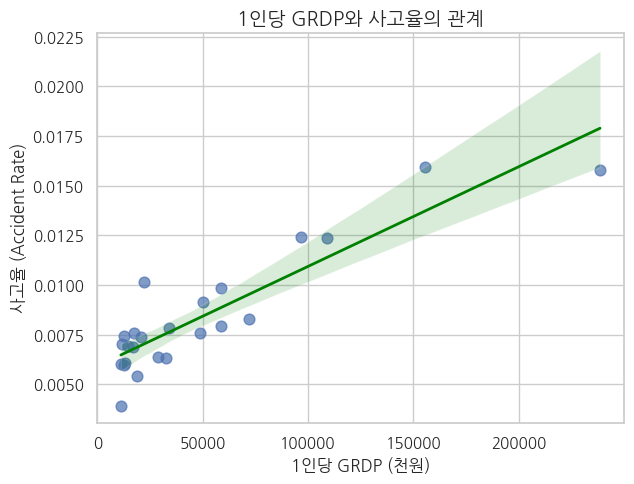

In [41]:
# 2. 가설 2: 1인당 GRDP가 높을수록 사고율이 낮다
plt.figure(figsize=(6.5, 5))
sns.regplot(
    x='gdp_per_capita',
    y='accident_rate',
    data=merged_df,
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'green', 'linewidth': 2}
)
plt.title('1인당 GRDP와 사고율의 관계', fontsize=14)
plt.xlabel('1인당 GRDP (천원)', fontsize=12)
plt.ylabel('사고율 (Accident Rate)', fontsize=12)
plt.tight_layout()
plt.show()

가설2: 경제력(GDP)과 사고 지표 전반의 상관관계 분석 (heatmap)

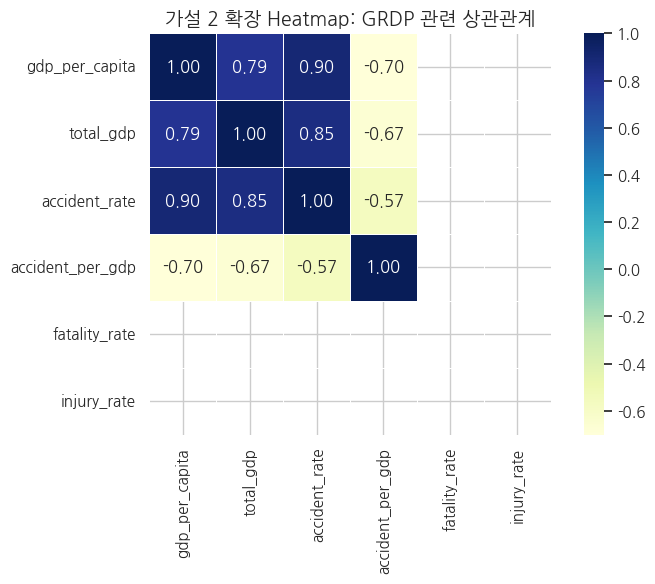

In [42]:
# 가설 2 관련 heatmap
hypo2_cols = [
    'gdp_per_capita',
    'total_gdp',
    'accident_rate',
    'accident_per_gdp',
    'fatality_rate',
    'injury_rate'
]
plt.figure(figsize=(8, 6))
sns.heatmap(
    merged_df[hypo2_cols].corr(),
    annot=True, cmap='YlGnBu', fmt=".2f",
    linewidths=0.5, square=True
)
plt.title('가설 2 확장 Heatmap: GRDP 관련 상관관계', fontsize=14)
plt.tight_layout()
plt.show()

3. 가설 3: 클러스터별 차량당 사고율 차이 존재

/tmp/ipython-input-43-1862818297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


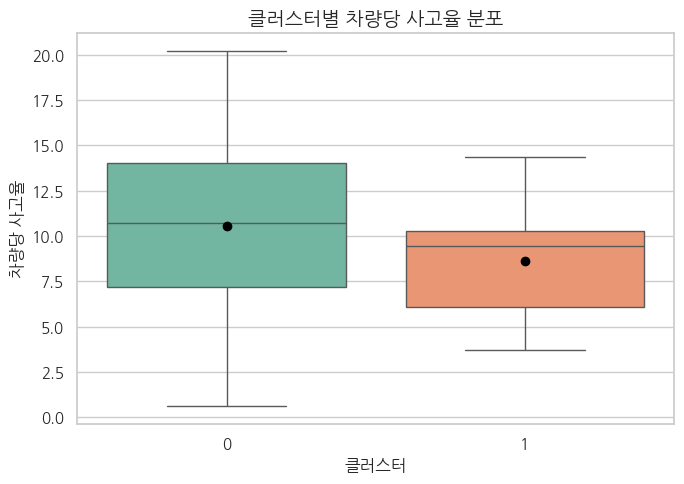

In [43]:
# 3. 가설 3: 클러스터별 차량당 사고율 차이 존재
plt.figure(figsize=(7, 5))
sns.boxplot(
    x='cluster',
    y='accident_per_vehicle',
    data=cluster_df,
    palette='Set2',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black"}
)
plt.title('클러스터별 차량당 사고율 분포', fontsize=14)
plt.xlabel('클러스터', fontsize=12)
plt.ylabel('차량당 사고율', fontsize=12)
plt.tight_layout()
plt.show()

클러스터 내 주요 지표 간의 상호작용 확인 (heatmap)

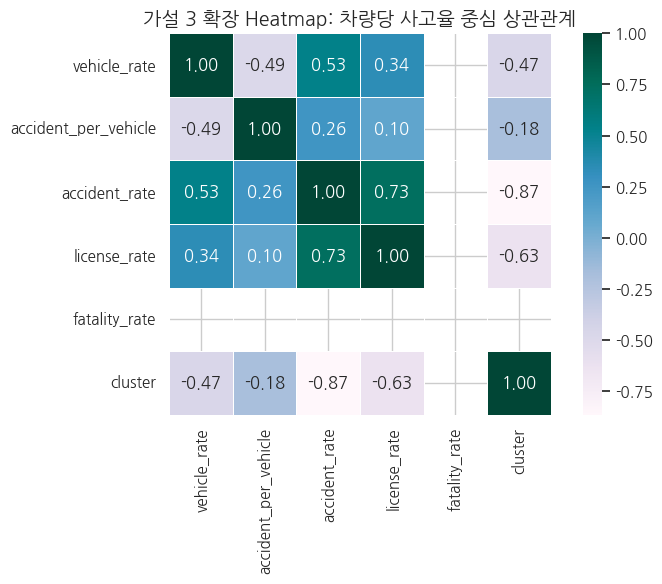

In [44]:
# 가설 3 관련 heatmap
hypo3_cols = [
    'vehicle_rate',
    'accident_per_vehicle',
    'accident_rate',
    'license_rate',
    'fatality_rate',
    'cluster'
]
# cluster가 숫자이므로 포함해도 상관 없음
plt.figure(figsize=(8, 6))
sns.heatmap(
    cluster_df[hypo3_cols].corr(),
    annot=True, cmap='PuBuGn', fmt=".2f",
    linewidths=0.5, square=True
)
plt.title('가설 3 확장 Heatmap: 차량당 사고율 중심 상관관계', fontsize=14)
plt.tight_layout()
plt.show()

# 고위험, 저위험 자치구 확인
- 클러스터 0, 1에 각각 해당하는 자치구 출력해서 확인
- 발표 자료 제작용

In [45]:
# 클러스터별 region_code 출력

# merged_df에 'region_code'와 'cluster' 컬럼이 이미 존재한다고 가정
clusters = merged_df['cluster'].unique()

for cl in sorted(clusters):
    codes = merged_df.loc[merged_df['cluster'] == cl, 'region_code'].tolist()
    print(f"클러스터 {cl} region_code:", codes)

클러스터 0 region_code: ['111123', '111231', '111261', '111262']
클러스터 1 region_code: ['111131', '111141', '111142', '111151', '111152', '111161', '111171', '111181', '111191', '111201', '111212', '111221', '111241', '111251', '111273', '111274', '111281', '111291', '111301', '111311']
